In [43]:
import geopandas as gpd
import os
import numpy as np
import matplotlib.pyplot as plt
from copy import deepcopy
from datetime import timedelta



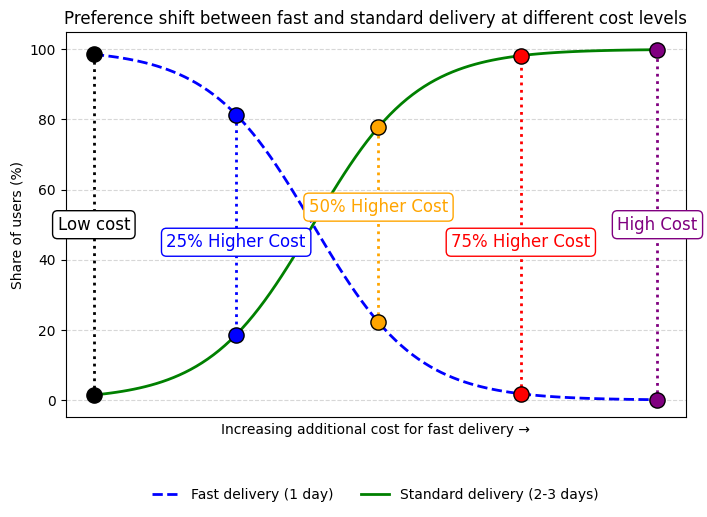

In [44]:
# Plot from EWGT 2025 Abstract

# Define price values (cost increasing)
price = np.linspace(1, 10, 100)  # Price from 1 to 10

# Demand distribution between fast and standard delivery (summing to 100%)
fast_delivery_share = 100 / (1 + np.exp(1.2 * (price - 4.5)))  # Fast delivery preference decreases with price
standard_delivery_share = 100 - fast_delivery_share  # Standard delivery preference increases accordingly

# Define cost-based sample points at 0%, 25%, 50%, 75%, and 100% of the cost range
cost_levels = [0.0, 0.25, 0.50, 0.75, 0.99]  # Avoid index out of range by using 0.99 instead of 1.0
sample_prices = [price[int(len(price) * c)] for c in cost_levels]  # Select corresponding price points

# Compute the corresponding fast and standard delivery shares
fast_shares = [fast_delivery_share[np.argmin(np.abs(price - p))] for p in sample_prices]
standard_shares = [100 - fs for fs in fast_shares]

# Define colors for scenarios
scenario_colors = ["black", "blue", "orange", "red", "purple"]
# Define updated labels based on cost levels rather than share percentages
scenario_labels = ["Low cost", "25% Higher Cost", "50% Higher Cost", "75% Higher Cost", "High Cost"]


label_offsets = [0, -5, 5, -5, 0]  # Adjust vertical position of text labels

# Create the plot again with improved label placement
plt.figure(figsize=(8, 5))
plt.plot(price, fast_delivery_share, label="Fast delivery (1 day)", linewidth=2, linestyle="dashed", color="blue")
plt.plot(price, standard_delivery_share, label="Standard delivery (2-3 days)", linewidth=2, color="green")

# Mark sample scenarios with same-colored points and connect them with vertical dashed lines
for i, (p, f, s) in enumerate(zip(sample_prices, fast_shares, standard_shares)):
    plt.scatter(p, f, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Fast delivery point
    plt.scatter(p, s, color=scenario_colors[i], s=120, edgecolors="black", zorder=3)  # Standard delivery point
    plt.plot([p, p], [f, s], color=scenario_colors[i], linestyle="dotted", linewidth=2, zorder=2)  # Vertical connector
    plt.text(p, (f + s) / 2 + label_offsets[i], scenario_labels[i], fontsize=12, color=scenario_colors[i],
             ha="center", va="center", bbox=dict(facecolor="white", edgecolor=scenario_colors[i], boxstyle="round,pad=0.3"))

# Adjust labels
plt.xlabel("Increasing additional cost for fast delivery →")
plt.ylabel("Share of users (%)")
plt.title("Preference shift between fast and standard delivery at different cost levels")

# Grid and legend below the plot
plt.grid(True, linestyle="dashed", alpha=0.5)
plt.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=2, frameon=False)

# Remove x-axis ticks
plt.xticks([])

plt.show()



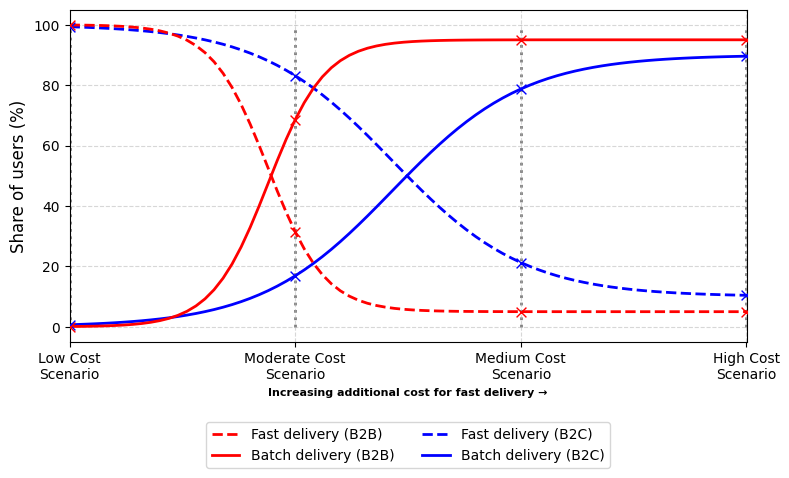

In [45]:
# Jetzt: Vertikale Linien = Szenariofarbe | Kreuze = Linienfarbe (B2B/Neutral/B2C)
import numpy as np
import matplotlib.pyplot as plt

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte

sample_prices = [price[int(len(price) * c)] for c in cost_levels]

scenario_labels = [
    "Low Cost\nScenario",
    "Moderate Cost\nScenario",
    "Medium Cost\nScenario",
    "High Cost\nScenario"
]

# Scenario colors for vertical lines
scenario_colors = ["black", "blue", "red", "red", "purple"]

# Curve colors for crosses
curve_colors = {
    "fast_b2c": "blue",
    "batch_b2c": "blue",
    "fast_neutral": "green",
    "batch_neutral": "green",
    "fast_b2b": "red",
    "batch_b2b": "red"
}

# Create the plot
plt.figure(figsize=(8, 5))

# Plot curves
plt.plot(price, fast_delivery_b2c, linestyle="--", color="blue", linewidth=2, label="Fast delivery (B2C)")
plt.plot(price, batch_delivery_b2c, linestyle="-", color="blue", linewidth=2, label="Batch delivery (B2C)")

# plt.plot(price, fast_delivery_neutral, linestyle="--", color="green", linewidth=2, label="Fast delivery (Neutral)")
# plt.plot(price, batch_delivery_neutral, linestyle="-", color="green", linewidth=2, label="Batch delivery (Neutral)")

plt.plot(price, fast_delivery_b2b, linestyle="--", color="red", linewidth=2, label="Fast delivery (B2B)")
plt.plot(price, batch_delivery_b2b, linestyle="-", color="red", linewidth=2, label="Batch delivery (B2B)")

# Add vertical lines and crosses at intersections
for i, p in enumerate(sample_prices):
    scenario_color = scenario_colors[i]
    
    # Vertical line from 0 to 100 in scenario color
    plt.plot([p, p], [0, 100], color="gray", linestyle="dotted", linewidth=2, zorder=1)
    
    # Find closest index
    idx = np.argmin(np.abs(price - p))
    
    # Plot crosses in curve color
    plt.scatter(p, fast_delivery_b2c[idx], color=curve_colors["fast_b2c"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2c[idx], color=curve_colors["batch_b2c"], marker='x', s=50, linewidths=1, zorder=3)

    
    plt.scatter(p, fast_delivery_b2b[idx], color=curve_colors["fast_b2b"], marker='x', s=50, linewidths=1, zorder=3)
    plt.scatter(p, batch_delivery_b2b[idx], color=curve_colors["batch_b2b"], marker='x', s=50, linewidths=1, zorder=3)

# Style settings
plt.xlabel("Increasing additional cost for fast delivery →", fontsize=8,fontweight='bold')
plt.xticks(sample_prices, scenario_labels, rotation=00, ha="center", fontsize=10)

plt.ylabel("Share of users (%)", fontsize=12)
# plt.title("Preferences Shift between fast and standard delivery at different cost levels for B2B and B2C parcel delivieries", pad=20)
# plt.xticks([])
plt.ylim(-5, 105)
plt.grid(True, linestyle="dashed", alpha=0.5)

plt.xlim(1, 7.82)  # weil price von 1 bis 10 geht

# Legend (manuell sortiert)
handles, labels = plt.gca().get_legend_handles_labels()
label_handle_dict = dict(zip(labels, handles))

desired_order = [
    "Fast delivery (B2B)",
    "Batch delivery (B2B)",
    "Fast delivery (B2C)",
    "Batch delivery (B2C)"
]

sorted_handles = [label_handle_dict[label] for label in desired_order]
sorted_labels = desired_order

plt.legend(sorted_handles, sorted_labels, loc="upper center", bbox_to_anchor=(0.5, -0.22), ncol=2, frameon=True, fontsize=10)

plt.tight_layout()
plt.show()



In [46]:
def load_all_hagrid_shapefiles(output_dir="output", prefix="hagrid_parcel_demand"):
    """
    Loads all HAGRID Shapefiles from the specified output directory individually.

    Parameters
    ----------
    output_dir : str, default="output"
        Directory where the HAGRID shapefiles are stored.
    prefix : str, default="hagrid_parcel_demand"
        Common filename prefix to identify relevant shapefiles.

    Returns
    -------
    shapefile_dict : dict
        Dictionary where keys are filenames (without extension) and values are GeoDataFrames.
    """
    # Find all matching shapefiles
    shp_files = [f for f in os.listdir(output_dir) if f.endswith(".shp") and f.startswith(prefix)]

    if not shp_files:
        raise FileNotFoundError(f"No shapefiles starting with '{prefix}' found in '{output_dir}'.")

    # Load each shapefile into a dictionary
    shapefile_dict = {}
    for shp_file in sorted(shp_files):  # sorted() to keep chronological order
        path = os.path.join(output_dir, shp_file)
        gdf = gpd.read_file(path)
        key = os.path.splitext(shp_file)[0]  # filename without '.shp'
        shapefile_dict[key] = gdf

    return shapefile_dict

In [47]:
carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# Alle GDFs laden
hagrid_files = load_all_hagrid_shapefiles(output_dir="output")

for filename, gdf in hagrid_files.items():
    total_b2b = gdf[[col for col in gdf.columns if col.endswith('_b2b')]].sum().sum()
    total_b2c = gdf[[col for col in gdf.columns if col.endswith('_b2c')]].sum().sum()
    total_packages = total_b2b + total_b2c

    tag_cols = [tag for _, (_, tag, _) in carrier_columns.items() if tag in gdf.columns]
    type_cols = [typ for _, (_, _, typ) in carrier_columns.items() if typ in gdf.columns]
    total_tag = gdf[tag_cols].sum().sum()
    total_type = gdf[type_cols].sum().sum()
    total_tag_type = total_tag + total_type

    print("=" * 80)
    print(f"{filename}: B2B={total_b2b}, B2C={total_b2c}, Total={total_packages} | tag={total_tag}, type={total_type}, tag+type={total_tag_type}")
    
    for carrier, (prefix, _, _) in carrier_columns.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        b2b_sum = gdf[b2b_col].sum() if b2b_col in gdf.columns else 0
        b2c_sum = gdf[b2c_col].sum() if b2c_col in gdf.columns else 0

        print(f"  {carrier:<10} | B2B: {b2b_sum:>7} | B2C: {b2c_sum:>7}")

    print()


hagrid_parcel_demand_2025-05-09_(Friday): B2B=42062, B2C=153406, Total=195468 | tag=153406, type=42062, tag+type=195468
  Amazon     | B2B:     247 | B2C:   34959
  DHL        | B2B:    9654 | B2C:   70250
  DPD        | B2B:    3129 | B2C:   12721
  GLS        | B2B:    1202 | B2C:   12048
  Hermes     | B2B:     520 | B2C:   18422
  UPS        | B2B:   14649 | B2C:    3281
  FedEx/TNT  | B2B:   12661 | B2C:    1725

hagrid_parcel_demand_2025-05-10_(Saturday): B2B=32295, B2C=116957, Total=149252 | tag=116957, type=32295, tag+type=149252
  Amazon     | B2B:     186 | B2C:   26812
  DHL        | B2B:    7402 | B2C:   53803
  DPD        | B2B:    2808 | B2C:    9309
  GLS        | B2B:     911 | B2C:    9196
  Hermes     | B2B:     411 | B2C:   14018
  UPS        | B2B:   11065 | B2C:    2509
  FedEx/TNT  | B2B:    9512 | B2C:    1310

hagrid_parcel_demand_2025-05-12_(Monday): B2B=45148, B2C=164247, Total=209395 | tag=164247, type=45148, tag+type=209395
  Amazon     | B2B:     280 | B2C:

In [48]:
# ===============================
# Imports
# ===============================

from collections import defaultdict
import numpy as np
import pandas as pd
import datetime
import matplotlib.pyplot as plt
from tqdm import tqdm
import logging

import copy
import re



# ===============================
# Logger Setup
# ===============================

logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
LOGGER = logging.getLogger(__name__)

# ===============================
# Parameters and Scenario Settings
# ===============================

# Preisachse
price = np.linspace(1, 10, 100)

# Preis minimal verschieben für Modellierung
price_shifted = price - 1.25

# B2C-Modell
fast_delivery_b2c = 10 + (90) / (1 + np.exp(1.5 * (price_shifted - 3)))
batch_delivery_b2c = 100 - fast_delivery_b2c

# B2B-Modell
fast_delivery_b2b = 5 + (95) / (1 + np.exp(3.5 * (price_shifted - 1.75)))
batch_delivery_b2b = 100 - fast_delivery_b2b

# Cost levels
cost_levels = [0.0, 0.25, 0.5, 0.75]  # Nur vier Punkte
cost_labels = ['low_cost', 'moderate_cost', 'medium_cost', 'high_cost']

scenario_probs = {}
for cost, label in zip(cost_levels, cost_labels):
    idx = int(len(price) * cost)
    scenario_probs[label] = {
        'b2c': {'fast': fast_delivery_b2c[idx] / 100, 'batch': batch_delivery_b2c[idx] / 100},
        'b2b': {'fast': fast_delivery_b2b[idx] / 100, 'batch': batch_delivery_b2b[idx] / 100}
    }

scenario_probs['full_scenario'] = {
    'b2c': {'fast': 0.0, 'batch': 1.0},
    'b2b': {'fast': 0.0, 'batch': 1.0}
}

carrier_days = {
    'DHL': ['Monday', 'Wednesday', 'Friday'],
    'Hermes': ['Tuesday', 'Saturday'],
    'DPD': ['Tuesday', 'Friday'],
    'GLS': ['Monday', 'Thursday'],
    'UPS': ['Monday', 'Thursday'],
    'Amazon': ['Tuesday', 'Thursday', 'Saturday'],
    'FedEx/TNT': ['Monday', 'Thursday']
}

# carrier_days = {
#     'DHL': ['Monday', 'Friday'],
#     'Hermes': ['Monday', 'Friday'],
#     'DPD': ['Monday', 'Friday'],
#     'GLS': ['Monday', 'Friday'],
#     'UPS': ['Monday', 'Friday'],
#     'Amazon': ['Monday', 'Friday'],
#     'FedEx/TNT': ['Monday', 'Friday']
# }

carrier_columns = {
    'Amazon': ('ama', 'amazon_tag', 'amazon_typ'),
    'DHL': ('dhl', 'dhl_tag', 'dhl_type'),
    'DPD': ('dpd', 'dpd_tag', 'dpd_type'),
    'GLS': ('gls', 'gls_tag', 'gls_type'),
    'Hermes': ('her', 'hermes_tag', 'hermes_typ'),
    'UPS': ('ups', 'ups_tag', 'ups_type'),
    'FedEx/TNT': ('fxt', 'fedex_tag', 'fedex_type')
}

# ===============================
# Helper Functions
# ===============================

def find_source_days_since_last_delivery(current_day, carrier_days_mapping, carrier):
    """
    Collect source days for current_day if it is a delivery day for the carrier.
    Otherwise, return empty (no delivery today).
    """

    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    day_idx = days_order.index(current_day)
    carrier_delivery_days = carrier_days_mapping.get(carrier, [])

    # >>>>> NEW: Check if carrier delivers today
    if current_day not in carrier_delivery_days:
        return []  # No delivery today

    source_days = []
    for offset in range(1, len(days_order)):
        previous_idx = (day_idx - offset) % len(days_order)
        previous_day = days_order[previous_idx]
        
        if previous_day in carrier_delivery_days:
            break  # STOP, previous delivery day found
        
        source_days.append(previous_day)

    source_days.reverse()
    return source_days    


def get_geodataframes(hagrid_files_thisweek, source_days, base_date, days, current_date):
    if source_days is None:
        return {}

    result = {}
    days_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    weekday_map = {'Monday': 0, 'Tuesday': 1, 'Wednesday': 2, 'Thursday': 3, 'Friday': 4, 'Saturday': 5}

    def get_previous_weekday(current_date, target_weekday):
        days_diff = (current_date.weekday() - target_weekday) % 7
        return current_date - timedelta(days=days_diff or 7)

    for day in source_days:
        if day not in days_order:
            raise ValueError(f"Invalid day: {day}")

        target_date = get_previous_weekday(current_date, weekday_map[day])

        # === Validierungen:
        assert target_date <= current_date, f"Calculated target_date {target_date} is after current_date {current_date}!"
        assert target_date.weekday() == weekday_map[day], (
            f"Calculated target_date {target_date} is not a {day}! (got weekday {target_date.weekday()})"
        )

        date_str = target_date.strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"

        LOGGER.info(f"Fetching source {day}: {key} (target_date: {target_date})")

        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")

        result[day] = hagrid_files_thisweek[key].copy(deep=True)

    return result



def assign_tags_types_wltag(new_week):
    """
    For each day and each carrier, assign b2c counts to _tag, b2b counts to _type, 
    and update wl_tag and total columns. Includes a final assert check.
    """
    for day, df in new_week.items():
        LOGGER.info(f"Assigning tags/types for {day}...")

        # 1. B2C -> _tag, B2B -> _type
        for carrier, (prefix, tag_col, type_col) in carrier_columns.items():
            if f"{prefix}_b2c" in df.columns and f"{prefix}_b2b" in df.columns:
                df[tag_col] = df[f"{prefix}_b2c"]
                df[type_col] = df[f"{prefix}_b2b"]

        # 2. wl_tag = Summe aller _tag und _type Spalten
        tag_cols = [v[1] for v in carrier_columns.values()]
        type_cols = [v[2] for v in carrier_columns.values()]
        df['wl_tag'] = df[tag_cols + type_cols].sum(axis=1)

        # 3. total = Summe aller _b2b und _b2c Spalten
        df['total'] = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].sum(axis=1)

        # 4. Harte Endprüfung: Summe total == wl_tag
        total_sum = df['total'].sum()
        wl_tag_sum = df['wl_tag'].sum()

        LOGGER.info(f"Validation totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}")

        assert np.isclose(total_sum, wl_tag_sum), (
            f"Mismatch in totals for {day}: total={total_sum}, wl_tag={wl_tag_sum}"
        )

WEEKDAYS_EN = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
def find_next_delivery_date(current_date: datetime.date, carrier: str, carrier_days: dict) -> datetime.date | None:
    delivery_days = carrier_days.get(carrier)
    if not delivery_days:
        LOGGER.info(f"{carrier}: No delivery days defined.")
        return None  # Falls der Carrier nicht existiert
    
    for offset in range(1, 7):  # Bis zu 2 Wochen nach vorne prüfen        
        candidate_date = current_date + datetime.timedelta(days=offset)
        weekday_name = WEEKDAYS_EN[candidate_date.weekday()]
        if weekday_name in delivery_days:
            return candidate_date  # Sofort zurückgeben
    LOGGER.info(f"{carrier}: No delivery day found within 1 weeks after {current_date}")
    return None 

def build_days_list(start_date: datetime.date, days: list = None):
    """
    Erzeugt eine Liste mit echten Tagesnamen ('Monday', 'Tuesday', ...) 
    und Mapping von Datum zu Tag.

    Args:
        start_date (datetime.date): Startdatum der Simulation.
        days (list, optional): Liste der Wochentage (z.B. ['Monday', 'Tuesday', ...]).
                               Falls None, wird automatisch ['Monday', ..., 'Saturday'] erzeugt.

    Returns:
        days (list of str): ['Monday', 'Tuesday', ..., 'Saturday']
        date_to_day (dict): {datetime.date: 'Monday', ...}
    """
    if days is None:
        days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

    num_days = len(days)
    date_to_day = {}
    for i in range(num_days):
        current_date = start_date + datetime.timedelta(days=i)
        day_name = current_date.strftime('%A')
        assert day_name == days[i], (
            f"Mismatch at day {i}: expected {days[i]} but got {day_name} from date {current_date}"
        )
        date_to_day[current_date] = day_name

    return days, date_to_day


def handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, probs):

    weekday_map = {
        'Montag': 'Monday',
        'Dienstag': 'Tuesday',
        'Mittwoch': 'Wednesday',
        'Donnerstag': 'Thursday',
        'Freitag': 'Friday',
        'Samstag': 'Saturday',
        'Sonntag': 'Sunday'
    }


    LOGGER.info("=" * 60)
    LOGGER.info(" *** STARTING POST-PROCESS: HANDLE FUTURE DELIVERIES OUTSIDE SIMULATION ***")
    LOGGER.info("=" * 60)

    total_removed = 0
    available_days = list(new_week.keys())
    available_dates = set(day_to_date.values())
    LOGGER.info(f"Available days: {available_days}")
    LOGGER.info(f"Available dates: {available_dates}")

    change_log = []
    for current_day in available_days:
        current_date = day_to_date[current_day]

        for carrier, (prefix, _, _) in carrier_columns.items():

            df = new_week[current_day]
            b2b_col = f"{prefix}_b2b"
            b2c_col = f"{prefix}_b2c"
            if b2b_col not in df.columns and b2c_col not in df.columns:
                continue

            # Finde nächstes Zustelldatum
            next_delivery_date = find_next_delivery_date(current_date, carrier, carrier_days)
            LOGGER.info(f"{carrier}: {current_day}. Next found delivery day: {next_delivery_date} ")

            if current_day in carrier_days.get(carrier, []):
                LOGGER.info(f"{carrier}: {current_day} is an actual delivery day – skipping postprocessing.")
                continue

            # Jetzt: Wenn dieser nächste Zustelltag NICHT in der Simulationswoche liegt
            if next_delivery_date not in available_dates:
                LOGGER.info(f"{carrier}: {current_day} collects for next delivery on {next_delivery_date} (outside simulation) → removing batch!")
                LOGGER.info(
                    f"{carrier}: Removing batch packages from {current_day} (date: {current_date}) "
                    f"→ would deliver on {next_delivery_date.strftime('%A')} ({next_delivery_date})"
                )

                b2b_vals = df.get(b2b_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)
                b2c_vals = df.get(b2c_col, pd.Series(0, index=df.index)).fillna(0).clip(lower=0).astype(int)

                total_b2b = b2b_vals.sum()
                total_b2c = b2c_vals.sum()


                if total_b2b > 0:
                    fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
                    fast_b2b_count = fast_flags_b2b.sum()
                    batch_b2b_count = total_b2b - fast_b2b_count
                else:
                    fast_b2b_count = batch_b2b_count = 0

                if total_b2c > 0:
                    fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
                    fast_b2c_count = fast_flags_b2c.sum()
                    batch_b2c_count = total_b2c - fast_b2c_count
                else:
                    fast_b2c_count = batch_b2c_count = 0

                dest_date_value = next_delivery_date
                source_date_value = pd.to_datetime(day_to_date[current_day]).date()

                weekday_de = next_delivery_date.strftime('%A')
                weekday_en = weekday_map.get(weekday_de, weekday_de)


                change_log.append({
                    "carrier": carrier,
                    "source_day": current_day,
                    "source_date": source_date_value,
                    "dest_day": weekday_en,
                    "dest_date": dest_date_value,
                    "b2b_batch": batch_b2b_count,
                    "b2c_batch": batch_b2c_count,
                    "b2b_fast": fast_b2b_count,
                    "b2c_fast": fast_b2c_count
                })


            else:
                LOGGER.info(
                    f"{carrier}: Next delivery after {current_day} ({current_date}) is {next_delivery_date.strftime('%A')} ({next_delivery_date}) "
                    f"→ within simulation window → skipping batch removal."
                )

    return change_log



def initialize_simulation_data(hagrid_files_thisweek, days, start_date):
    """Initializes data for each day in the simulation week."""
    hagrid_files_original = {k: v.copy(deep=True) for k, v in hagrid_files_thisweek.items()}
    new_week = {}
    for i, day in enumerate(days):
        date_str = (start_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        df = hagrid_files_thisweek[key].copy(deep = True)
        new_week[day] = df
        LOGGER.info(f"Loaded and initialized data for {day}.")
    return hagrid_files_original, new_week

def simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, probs, day_to_date):
    """Simulates batch deliveries for all carriers on a specific day."""
    all_changes = []
    for carrier in carrier_columns.keys():
        if current_day not in carrier_days.get(carrier, []):
            LOGGER.info(f"{carrier} does not have a batch delivery on {current_day}. Skipping.")
            continue

        current_date = day_to_date[current_day]
        source_days_for_carrier = find_source_days_since_last_delivery(current_day, carrier_days, carrier)
        sourceDaysDeliveries = get_geodataframes(hagrid_files_original, source_days_for_carrier, start_date, days, current_date)

        for source_day, source_day_gdf in sourceDaysDeliveries.items():
            LOGGER.info(f"Source day {source_day} for {carrier}: {len(source_day_gdf)} rows and date {source_day_gdf['date'].unique()}")

        prefix, _, _ = carrier_columns[carrier]
        
        if not source_days_for_carrier:
            LOGGER.info(f"No source days found for {carrier} on {current_day}.")
            continue

        changes = assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date)
        all_changes.extend(changes)
    return all_changes

def aggregate_day_changes(change_df):
    """Aggregates batch changes across days and carriers."""
    carriers = change_df['carrier'].unique()
    all_dates = pd.unique(change_df[['source_date', 'dest_date']].values.ravel())

    day_changes = pd.DataFrame(0, index=pd.MultiIndex.from_product([carriers, all_dates], names=['carrier', 'date']),
                               columns=['b2b_delta', 'b2c_delta'])

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']

        day_changes.loc[(carrier, dst_date), 'b2b_delta'] += row['b2b_batch']
        day_changes.loc[(carrier, dst_date), 'b2c_delta'] += row['b2c_batch']
        day_changes.loc[(carrier, src_date), 'b2b_delta'] -= row['b2b_batch']
        day_changes.loc[(carrier, src_date), 'b2c_delta'] -= row['b2c_batch']

    summary_per_date = day_changes.groupby('date')[['b2b_delta', 'b2c_delta']].sum()
    summary_per_date['total_delta'] = summary_per_date['b2b_delta'] + summary_per_date['b2c_delta']
    return summary_per_date

def merge_post_simulation_changes(summary_per_date, post_changes, original_df):
    """Merges post-simulation adjustments into the main summary."""
    post_change_df = pd.DataFrame(post_changes).rename(columns={'source_date': 'date'})

    post_change_df['b2b_batch'] = -post_change_df['b2b_batch']
    post_change_df['b2c_batch'] = -post_change_df['b2c_batch']
    post_change_df['total_delta'] = post_change_df['b2b_batch'] + post_change_df['b2c_batch']

    post_change_summary = post_change_df.groupby('date')[['b2b_batch', 'b2c_batch', 'total_delta']].sum()

    final_summary = summary_per_date.merge(
        post_change_summary,
        on='date',
        how='outer',
        suffixes=('', '_post')
    ).fillna(0)

    final_summary['b2b_final'] = final_summary['b2b_delta'] + final_summary['b2b_batch']
    final_summary['b2c_final'] = final_summary['b2c_delta'] + final_summary['b2c_batch']
    final_summary['total_final'] = final_summary['b2b_final'] + final_summary['b2c_final']

    return final_summary

def collect_original_totals(hagrid_files_thisweek):
    """Collects the original package totals per date from input data."""
    original_totals = {}
    for key, df in hagrid_files_thisweek.items():
        b2b_cols = [col for col in df.columns if col.endswith('_b2b')]
        b2c_cols = [col for col in df.columns if col.endswith('_b2c')]
        total_b2b = df[b2b_cols].fillna(0).sum().sum()
        total_b2c = df[b2c_cols].fillna(0).sum().sum()
        original_totals[key] = total_b2b + total_b2c

    original_totals_parsed = {}
    for key, total in original_totals.items():
        match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
        if match:
            date = pd.to_datetime(match.group(1)).date()
            original_totals_parsed[date] = total

    return pd.DataFrame.from_dict(original_totals_parsed, orient='index', columns=['original_total']).rename_axis('date')

def build_final_carrier_date_deltas(day_changes, post_changes, final_summary):
    """
    Combines day_changes (batch simulation results) and post_changes (post-simulation adjustments)
    into a consolidated DataFrame with MultiIndex (carrier, date) and columns:
    b2b_delta, b2c_delta, total_delta.

    Also validates:
    1. That per date: sum(b2b_delta + b2c_delta) == total_delta
    2. That aggregated totals match final_summary values

    Raises ValueError if discrepancies are found.
    """
    # Convert post_changes to DataFrame if necessary
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  

    if 'date' not in final_summary.columns:
        final_summary = final_summary.reset_index()

    post_changes_df = post_changes[['carrier', 'source_date', 'b2b_batch', 'b2c_batch']].copy()
    post_changes_df = post_changes_df.rename(columns={'source_date': 'date'})
    post_changes_df['b2b_delta'] = - post_changes_df['b2b_batch']
    post_changes_df['b2c_delta'] = - post_changes_df['b2c_batch']
    post_changes_df['total_delta'] = post_changes_df['b2b_delta'] + post_changes_df['b2c_delta']
    post_changes_df_prepared = post_changes_df[['carrier', 'date', 'b2b_delta', 'b2c_delta', 'total_delta']]

    combined_changes = pd.concat([day_changes.reset_index(), post_changes_df_prepared], axis=0)
    final_deltas = combined_changes.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta', 'total_delta']].sum()    
    final_deltas_per_date = final_deltas.groupby('date')[['total_delta']].sum().reset_index()

    # Merge beide
    merged_check = final_deltas_per_date.merge(final_summary[['date', 'total_final']], on='date', how='outer')    
    merged_check['diff'] = merged_check['total_delta'] - merged_check['total_final']

    # Prüfe Abweichungen
    if not merged_check[np.abs(merged_check['diff']) > 1e-6].empty:
        raise ValueError(f"Mismatch between total_delta and total_final!\n{merged_check[merged_check['diff'].abs() > 1e-6]}")
    else:
        LOGGER.info("✅ Validation passed: total_delta equals total_final for each date.")
        
    return final_deltas

def build_carrier_date_deltas_from_change_df(change_df):
    """
    Builds a DataFrame with carrier, date, b2b_delta, b2c_delta from change_df.
    """
    records = []

    for _, row in change_df.iterrows():
        carrier = row['carrier']
        src_date = row['source_date']
        dst_date = row['dest_date']
        b2b = row['b2b_batch']
        b2c = row['b2c_batch']

        # Add positive delta to dest_date
        records.append({'carrier': carrier, 'date': dst_date, 'b2b_delta': b2b, 'b2c_delta': b2c})

        # Add negative delta to src_date
        records.append({'carrier': carrier, 'date': src_date, 'b2b_delta': -b2b, 'b2c_delta': -b2c})

    df = pd.DataFrame(records)
    df = df.groupby(['carrier', 'date'])[['b2b_delta', 'b2c_delta']].sum()
    df['total_delta'] = df['b2b_delta'] + df['b2c_delta']

    return df

def extract_date_from_key(key):
    import re
    match = re.search(r'_(\d{4}-\d{2}-\d{2})_', key)
    if match:
        return pd.to_datetime(match.group(1)).date()
    raise ValueError(f"Cannot extract date from key: {key}")

def plot_week_comparison(hagrid_files_original, new_week, day_to_date):
    """
    Plots total packages per day: original vs simulated (new_week).
    """
    original_totals = {}
    new_totals = {}

    for key, df in hagrid_files_original.items():
        date = extract_date_from_key(key)
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        original_totals[date] = total

    for day, df in new_week.items():
        total = df[[col for col in df.columns if col.endswith('_b2b') or col.endswith('_b2c')]].fillna(0).sum().sum()
        new_totals[day_to_date[day]] = total  # convert day → date

    # to DataFrame
    original_df = pd.DataFrame.from_dict(original_totals, orient='index', columns=['original_total'])
    
    new_df = pd.DataFrame.from_dict(new_totals, orient='index', columns=['simulated_total'])
    original_df = original_df.loc[original_df.index.isin(new_df.index)]

    plot_df = original_df.join(new_df, how='outer').fillna(0)
    plot_df = plot_df.sort_index()

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df.index]
    x = np.arange(len(x_labels))
    width = 0.4

    plt.figure(figsize=(12,6))
    plt.bar(x - width/2, plot_df['original_total'], width, label='Original')
    plt.bar(x + width/2, plot_df['simulated_total'], width, label='Simulated')
    plt.xticks(x, x_labels, rotation=45)
    plt.ylabel('Pakete')
    plt.title('Original vs. Simulated Total Parcel Volumes After Data Processing')
    plt.legend()
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()


def plot_simulation_results(final_summary, original_df, sim_start_date):
    """Plots original vs simulated totals per date."""
    plot_df = original_df.merge(final_summary[['total_final']], on='date', how='left').fillna(0)
    plot_df['simulated_total'] = plot_df['original_total'] + plot_df['total_final']
    plot_df_filtered = plot_df[plot_df.index >= sim_start_date]

    x_labels = [d.strftime('%Y-%m-%d') if isinstance(d, datetime.date) else str(d) for d in plot_df_filtered.index]
    x = np.arange(len(x_labels))
    width = 0.4

    fig, ax = plt.subplots(figsize=(12,6))
    rects1 = ax.bar(x - width/2, plot_df_filtered['original_total'], width, label='Original')
    rects2 = ax.bar(x + width/2, plot_df_filtered['simulated_total'], width, label='Simulated')

    # 🟢 Hier: Werte direkt auf die Balken schreiben
    ax.bar_label(rects1, padding=3, fmt='%.0f')
    ax.bar_label(rects2, padding=3, fmt='%.0f')

    ax.set_xticks(x)
    ax.set_xticklabels(x_labels, rotation=45)
    ax.set_ylabel('Parcel')
    ax.set_title('Original vs. Simulated Total Parcel Volumes Before Data Processing')
    ax.legend()
    ax.grid(axis='y')
    plt.tight_layout()
    plt.show()

def process_carrier_date_delta(carrier, date, delta, eligible_df, col_name, new_week_day, lookup_coords_day):
    """
    Processes delta (b2b or b2c) for a given carrier + date:
    - distributes delta randomly over eligible rows
    - updates new_week_day DataFrame
    """
    if delta > 0:
        remaining_capacity = eligible_df[col_name]
        assigned = distribute_parcels(delta, remaining_capacity, strategy="random")
    elif delta < 0:
        LOGGER.error(f"Negative delta encountered for carrier {carrier} on {date}: {delta}")
        raise ValueError(f"Negative delta not supported for carrier {carrier} on {date}")
    else:
        assigned = pd.Series(0, index=eligible_df.index)

    for idx, amount in assigned.items():
        if amount <= 0:
            continue

        geometry_wkt = eligible_df.at[idx, 'geometry'].wkt if pd.notna(eligible_df.at[idx, 'geometry']) else None
        if geometry_wkt and geometry_wkt in lookup_coords_day:
            target_idx = lookup_coords_day[geometry_wkt]
            new_week_day.at[target_idx, col_name] += amount
        else:
            # Create new row
            new_row = pd.Series(0, index=new_week_day.columns)

            # Kopiere notwendige Identifikatoren
            for id_col in ['str_idx', 'name', 'postal_code', 'cell_id', 'geometry']:
                new_row[id_col] = eligible_df.at[idx, id_col]

            # Setze Carrier-Spalten
            new_row[col_name] = amount  # b2b oder b2c je nach Aufruf

            for other_carrier in carrier_columns:
                if other_carrier != carrier:
                    other_b2b_col = carrier_columns[other_carrier][1]
                    other_b2c_col = carrier_columns[other_carrier][2]
                    new_row[other_b2b_col] = 0
                    new_row[other_b2c_col] = 0

            # Berechne total_sim, total, wl_tag
            new_row['total_sim'] = sum(new_row[col] for col in new_week_day.columns if col.endswith('_b2b') or col.endswith('_b2c'))
            new_row['total'] = new_row['total_sim']
            new_row['wl_tag'] = new_row['total_sim']

            # Optional: auch tag/type-Spalten explizit nullen, falls nötig
            for col in new_week_day.columns:
                if '_tag' in col or '_type' in col:
                    new_row[col] = 0

            # Hänge neue Zeile an
            new_week_day = pd.concat([new_week_day, new_row.to_frame().T], ignore_index=True)

            # Update lookup
            lookup_coords_day[geometry_wkt] = new_week_day.index[-1]

    return new_week_day, lookup_coords_day

def validate_transfer_sums(source_df, target_df, b2b_col, b2c_col, source_day_name, target_day_name, carrier):
    initial_b2b_source = source_df[b2b_col].sum()
    initial_b2c_source = source_df[b2c_col].sum()
    initial_b2b_target = target_df[b2b_col].sum()
    initial_b2c_target = target_df[b2c_col].sum()

    total_b2b_before = initial_b2b_source + initial_b2b_target
    total_b2c_before = initial_b2c_source + initial_b2c_target

    LOGGER.debug(f"[{carrier}] Initial sums – {source_day_name}: B2B={initial_b2b_source}, B2C={initial_b2c_source}; "
                 f"{target_day_name}: B2B={initial_b2b_target}, B2C={initial_b2c_target}")

    def after_sums():
        b2b_source = source_df[b2b_col].sum()
        b2c_source = source_df[b2c_col].sum()
        b2b_target = target_df[b2b_col].sum()
        b2c_target = target_df[b2c_col].sum()
        return b2b_source, b2c_source, b2b_target, b2c_target

    b2b_source_after, b2c_source_after, b2b_target_after, b2c_target_after = after_sums()

    total_b2b_after = b2b_source_after + b2b_target_after
    total_b2c_after = b2c_source_after + b2c_target_after

    LOGGER.debug(f"[{carrier}] Final sums – {source_day_name}: B2B={b2b_source_after}, B2C={b2c_source_after}; "
                 f"{target_day_name}: B2B={b2b_target_after}, B2C={b2c_target_after}")

    assert np.isclose(total_b2b_before, total_b2b_after), \
        f"⚠️ B2B SUM MISMATCH for {carrier} ({source_day_name}→{target_day_name}): {total_b2b_before} → {total_b2b_after}"
    assert np.isclose(total_b2c_before, total_b2c_after), \
        f"⚠️ B2C SUM MISMATCH for {carrier} ({source_day_name}→{target_day_name}): {total_b2c_before} → {total_b2c_after}"

    LOGGER.info(f"✅ Validation passed for {carrier}: totals consistent from {source_day_name} → {target_day_name}")


def distribute_parcels(count, remaining_capacity, strategy="random", weights=None):
    """
    Distributes 'count' packages over available rows in remaining_capacity Series.
    
    Parameters:
        count (int): number of packages to assign
        remaining_capacity (pd.Series): index = row index, values = remaining capacity per row
        strategy (str): "random" or "weighted"
        weights (pd.Series or None): optional weights for weighted strategy

    Returns:
        pd.Series: index = same as remaining_capacity, values = assigned packages per row

    Raises:
        RuntimeError: if not enough capacity to assign all packages
    """

    assigned = pd.Series(0, index=remaining_capacity.index)
    to_assign = count

    # next_log_threshold = original_count - original_count // 4  # Start bei 75%

    if strategy == "random":
        while to_assign > 0:
            candidates = remaining_capacity[remaining_capacity > 0]
            if candidates.empty:
                raise RuntimeError(f"No candidates left to assign packages, but {to_assign} remain!")

            chosen_idx = np.random.choice(candidates.index)
            assigned.at[chosen_idx] += 1
            remaining_capacity.at[chosen_idx] -= 1
            to_assign -= 1

            # if to_assign <= next_log_threshold:
            #     LOGGER.info(f"➡️ distribute_parcels: {original_count - to_assign}/{original_count} assigned ({100*(original_count - to_assign)/original_count:.0f}%)")
            #     next_log_threshold -= original_count // 4  # nächstes 25% Intervall

    elif strategy == "weighted":
        raise NotImplementedError("Weighted strategy not implemented yet.")

    else:
        raise ValueError(f"Unknown strategy: {strategy}")

    return assigned

def subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date):
    """
    Subtracts b2b_delta and b2c_delta at source_date (randomly distributed over rows with >0).
    """
    day = [k for k,v in day_to_date.items() if v == source_date][0]  # find day-name for date
    df = new_week[day]

    prefix, _, _ = carrier_columns[carrier]

    b2b_col = f"{prefix}_b2b"
    b2c_col = f"{prefix}_b2c"

    # Filter rows where >0 packages exist
    eligible_b2b = df[df[b2b_col] > 0]
    eligible_b2c = df[df[b2c_col] > 0]


    if b2b_delta > 0:
        LOGGER.debug(f"Subtracting {b2b_delta} B2B from {carrier} on {source_date}")
        remaining_capacity = eligible_b2b[b2b_col].copy()
        assigned = distribute_parcels(b2b_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2b_col] -= amount
            assert df.at[idx, b2b_col] >= 0, f"B2B negative at idx {idx}"

    if b2c_delta > 0:
        LOGGER.debug(f"Subtracting {b2c_delta} B2C from {carrier} on {source_date}")
        remaining_capacity = eligible_b2c[b2c_col].copy()
        assigned = distribute_parcels(b2c_delta, remaining_capacity, strategy="random")

        for idx, amount in assigned.items():
            df.at[idx, b2c_col] -= amount
            assert df.at[idx, b2c_col] >= 0, f"B2C negative at idx {idx}"

    new_week[day] = df  # updated DataFrame rein (falls inplace nicht sicher)

def remove_at_source_date_and_add_at_current_date(
    carrier,
    hagrid_files_original,
    source_date,
    current_date,
    b2b_delta,
    b2c_delta,
    new_week,
    day_to_date,
    lookup_coords
):
    """
    Entfernt Pakete am source_date (auf Basis von hagrid_files_original) 
    und fügt sie am current_date in new_week hinzu.
    """

    # 1️⃣ → Determine the day names (if source_date is part of the simulation week)
    source_day_names = [day for day, date in day_to_date.items() if date == source_date]
    target_day_name = [day for day, date in day_to_date.items() if date == current_date][0]

    source_day_name = source_day_names[0] if source_day_names else None

    # 2️⃣ → Find the correct key from hagrid_files_original for source_date
    date_to_key = {}
    for key in hagrid_files_original.keys():
        try:
            date_part = key.split("_")[3]
            date_to_key[date_part] = key
        except IndexError:
            raise ValueError(f"Unexpected filename format: {key}")

    original_key = date_to_key.get(str(source_date))
    if original_key is None:
        raise KeyError(f"No original HAGRID data found for date {source_date}")

    # 3️⃣ → Get the original dataframe from hagrid_files_original
    original_df = hagrid_files_original[original_key].copy(deep=True)

    # 4️⃣ → Get current_df depending on whether source_date is inside simulation week
    if source_day_name is not None:
        # ✅ inside simulation week: work on the existing simulation data
        current_df = new_week[source_day_name]
    else:
        # 🟠 outside simulation week: work from a fresh copy of original data
        current_df = original_df.copy(deep=True)

    # 5️⃣ → Always get the target day dataframe from new_week
    target_df = new_week[target_day_name]

    # 6️⃣ → Build column names
    prefix, _, _ = carrier_columns[carrier]
    b2b_col = f"{prefix}_b2b"
    b2c_col = f"{prefix}_b2c"

    LOGGER.info(
        f"→ Transfer from {source_date} ({source_day_name or 'outside week'}) "
        f"to {current_date} ({target_day_name}) for {carrier}: "
        f"B2B={b2b_delta}, B2C={b2c_delta}"
    )

    # 4️⃣ → Hilfsfunktion: verteilt zu entfernende Pakete
    def subtract_packages(original_df, current_df, col, delta):
        eligible = original_df[original_df[col] > 0][col].copy()
        assigned = distribute_parcels(delta, eligible, strategy="random")
        for idx, amount in assigned.items():
            current_df.at[idx, col] -= amount
            assert current_df.at[idx, col] >= 0, f"{col} negative at idx {idx}"
        return assigned

    # 5️⃣ → Reduzieren am source day
    assigned_b2b = {}
    assigned_b2c = {}
    if b2b_delta > 0:
        LOGGER.debug(f"Subtracting {b2b_delta} B2B from {carrier} on {source_date}")
        assigned_b2b = subtract_packages(original_df, current_df, b2b_col, b2b_delta)

    if b2c_delta > 0:
        LOGGER.debug(f"Subtracting {b2c_delta} B2C from {carrier} on {source_date}")
        assigned_b2c = subtract_packages(original_df, current_df, b2c_col, b2c_delta)

    # 6️⃣ → Hinzufügen am target day (optimiert mit Mapping)
    new_rows_b2b = []
    new_rows_b2c = []
    new_coords_idx_b2b = {}  # geom_wkt → index in new_rows_b2b
    new_coords_idx_b2c = {}  # geom_wkt → index in new_rows_b2c

    for idx, amount in assigned_b2b.items():
        geom_wkt = original_df.at[idx, 'geometry'].wkt if pd.notna(original_df.at[idx, 'geometry']) else None
        if geom_wkt in lookup_coords[target_day_name]:
            target_idx = lookup_coords[target_day_name][geom_wkt]
            target_df.at[target_idx, b2b_col] += amount
            LOGGER.debug(f"→ B2B +{amount} added to EXISTING idx {target_idx} at {target_day_name}")
        elif geom_wkt in new_coords_idx_b2b:
            pending_idx = new_coords_idx_b2b[geom_wkt]
            new_rows_b2b[pending_idx][b2b_col] += amount
            LOGGER.debug(f"→ B2B +{amount} accumulated in pending new row at {target_day_name}")
        else:
            new_row = original_df.loc[idx].copy()
            for colname in new_row.index:
                if colname.endswith(('_b2b', '_b2c')):
                    new_row[colname] = 0
            new_row[b2b_col] = amount
            new_rows_b2b.append(new_row)
            new_coords_idx_b2b[geom_wkt] = len(new_rows_b2b) - 1
            LOGGER.debug(f"→ B2B +{amount} prepared as NEW row (pending) at {target_day_name}")

    for idx, amount in assigned_b2c.items():
        geom_wkt = original_df.at[idx, 'geometry'].wkt if pd.notna(original_df.at[idx, 'geometry']) else None
        if geom_wkt in lookup_coords[target_day_name]:
            target_idx = lookup_coords[target_day_name][geom_wkt]
            target_df.at[target_idx, b2c_col] += amount
            LOGGER.debug(f"→ B2C +{amount} added to EXISTING idx {target_idx} at {target_day_name}")
        elif geom_wkt in new_coords_idx_b2c:
            pending_idx = new_coords_idx_b2c[geom_wkt]
            new_rows_b2c[pending_idx][b2c_col] += amount
            LOGGER.debug(f"→ B2C +{amount} accumulated in pending new row at {target_day_name}")
        else:
            new_row = original_df.loc[idx].copy()
            for colname in new_row.index:
                if colname.endswith(('_b2b', '_b2c')):
                    new_row[colname] = 0
            new_row[b2c_col] = amount
            new_rows_b2c.append(new_row)
            new_coords_idx_b2c[geom_wkt] = len(new_rows_b2c) - 1
            LOGGER.debug(f"→ B2C +{amount} prepared as NEW row (pending) at {target_day_name}")

    # → Jetzt nur EIN concat pro Typ und Indexzuweisung
    if new_rows_b2b:
        start_idx = len(target_df)
        target_df = pd.concat([target_df, pd.DataFrame(new_rows_b2b)], ignore_index=True)
        for geom_wkt, pending_idx in new_coords_idx_b2b.items():
            lookup_coords[target_day_name][geom_wkt] = start_idx + pending_idx
            LOGGER.debug(f"→ B2B new row at idx {start_idx + pending_idx} finalized for {target_day_name}")

    if new_rows_b2c:
        start_idx = len(target_df)
        target_df = pd.concat([target_df, pd.DataFrame(new_rows_b2c)], ignore_index=True)
        for geom_wkt, pending_idx in new_coords_idx_b2c.items():
            lookup_coords[target_day_name][geom_wkt] = start_idx + pending_idx
            LOGGER.debug(f"→ B2C new row at idx {start_idx + pending_idx} finalized for {target_day_name}")

    # 7️⃣ → Write back only if source_day_name is inside simulation week
    if source_day_name is not None:
        new_week[source_day_name] = current_df

    # Always write target day
    new_week[target_day_name] = target_df

    # 8️⃣ → Validierung
    validate_transfer_sums(current_df, target_df, b2b_col, b2c_col, source_day_name, target_day_name, carrier)

def distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date):
    """
    Distributes final_deltas (carrier + date + b2b/b2c delta) into new_week DataFrames.
    For each carrier + date:
        - selects corresponding source day from hagrid_files_original
        - randomly picks b2b/b2c sendings to move
        - updates new_week[date]: existing rows (increment) or adds new row
    """
    # 1️⃣ Initialize lookup_coords: for each day → geometry.wkt → row index
    LOGGER.info("Initializing lookup_coords for new_week...")
    lookup_coords = {
        day: {row.geometry.wkt: idx for idx, row in df.iterrows() if pd.notna(row.geometry)}
        for day, df in new_week.items()
    }
    LOGGER.info("Lookup_coords initialized. Loaded %d geometries.", sum(len(v) for v in lookup_coords.values()))

    # 2️⃣ Loop over each carrier + date in final_deltas
    for (carrier, date), row in total_changes.iterrows():
        b2b_delta = row['b2b_batch']
        b2c_delta = row['b2c_batch']
        source_date = date
        dest_date = row['dest_date']

        LOGGER.debug(f"➡️ Processing {carrier}: {b2b_delta} B2B, {b2c_delta} B2C from {source_date} → {dest_date}")
                        
        if dest_date in day_to_date.values():
            if source_date in day_to_date.values():
                LOGGER.debug(f"🔄 Source {source_date} and destination {dest_date} BOTH inside simulation → SUBTRACT at source, ADD at destination")
            else:
                LOGGER.debug(f"🟢 Source {source_date} OUTSIDE simulation")
            remove_at_source_date_and_add_at_current_date(carrier, hagrid_files_original, source_date, dest_date, b2b_delta, b2c_delta, new_week, day_to_date, lookup_coords)

        elif source_date in day_to_date.values() and dest_date not in day_to_date.values():
            LOGGER.debug(f"🟠 Source {source_date} inside simulation but destination {dest_date} OUTSIDE → ONLY subtracting at source")
            subtract_at_source_date(carrier, source_date, b2b_delta, b2c_delta, new_week, day_to_date)

        elif source_date not in day_to_date.values() and dest_date not in day_to_date.values():
            # Fehler: weder Quelle noch Ziel in Simulation
            LOGGER.error(f"Invalid delivery: source_date {date} and dest_date {dest_date} both outside simulation!")
            raise ValueError(f"Cannot process delivery from {date} to {dest_date}: both outside simulation.")

    plot_week_comparison(hagrid_files_original, new_week, day_to_date)
    LOGGER.info("✅ Finished distributing results into new_week")
    return new_week

def assign_batch_deliveries(sourceDaysDeliveries, current_day, carrier, prefix, probs, day_to_date ):
    LOGGER.info(f"Starting assigning processing for {carrier} on {current_day}")
    change_log = []

    for source_day, source_day_gdf in sourceDaysDeliveries.items():
        b2b_col = f"{prefix}_b2b"
        b2c_col = f"{prefix}_b2c"

        LOGGER.info(f"{carrier} @ {source_day} - B2B Sum: {source_day_gdf[b2b_col].sum()}, B2C Sum: {source_day_gdf[b2c_col].sum()}")

        # --- Schritt 1: Paketzahlen holen ---
        b2b_vals = source_day_gdf.get(b2b_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)
        b2c_vals = source_day_gdf.get(b2c_col, pd.Series(0, index=source_day_gdf.index)).fillna(0).astype(int)

        total_b2b = b2b_vals.sum()
        total_b2c = b2c_vals.sum()

        # --- Schritt 2: Globale Monte Carlo Simulation ---
        if total_b2b > 0:
            fast_flags_b2b = np.random.rand(total_b2b) < probs['b2b']['fast']
            fast_b2b_count = fast_flags_b2b.sum()
            batch_b2b_count = total_b2b - fast_b2b_count
        else:
            fast_b2b_count = batch_b2b_count = 0

        if total_b2c > 0:
            fast_flags_b2c = np.random.rand(total_b2c) < probs['b2c']['fast']
            fast_b2c_count = fast_flags_b2c.sum()
            batch_b2c_count = total_b2c - fast_b2c_count
        else:
            fast_b2c_count = batch_b2c_count = 0

        source_date_value = pd.to_datetime(source_day_gdf['date'].iloc[0]).date()
        dest_date_value = pd.to_datetime(day_to_date[current_day]).date()

        change_log.append({
            "carrier": carrier,
            "source_day": source_day,
            "source_date": source_date_value,
            "dest_day": current_day,
            "dest_date": dest_date_value,
            "b2b_batch": batch_b2b_count,
            "b2c_batch": batch_b2c_count,
            "b2b_fast": fast_b2b_count,
            "b2c_fast": fast_b2c_count
        })

    LOGGER.info(f"Finished assigning deliveries for {carrier} on {current_day}")
    return change_log

def combine_changes(day_changes, post_changes):
    if isinstance(post_changes, list):
        post_changes = pd.DataFrame(post_changes)  
    result_total = pd.concat([day_changes, post_changes], ignore_index=True)
    result_total = result_total.set_index(['carrier', 'source_date'])    
    return result_total

# ===============================
# Simulation Functions
# ===============================

def simulate_full_existing_week(hagrid_files_thisweek, days, start_date, scenario='moderate_cost', random_seed=42):
    np.random.seed(random_seed)

    date_to_day = {start_date + datetime.timedelta(days=i): day for i, day in enumerate(days)}
    day_to_date = {day: date for date, day in date_to_day.items()}

    LOGGER.info(f"{'=' * 80}")
    LOGGER.info(f"STARTING WEEKLY SIMULATION FOR SCENARIO: {scenario.upper()}")
    LOGGER.info(f"{'=' * 80}")

    hagrid_files_original, new_week = initialize_simulation_data(hagrid_files_thisweek, days, start_date)

    all_changes = []
    for current_day in days:
        LOGGER.info("="*60)
        LOGGER.info(f" *** START BATCH SIMULATION FOR: {current_day.upper()} *** ")
        LOGGER.info("="*60)
        day_changes = simulate_day_for_carriers(current_day, carrier_columns, carrier_days, hagrid_files_original, start_date, days, scenario_probs[scenario], day_to_date)
        all_changes.extend(day_changes)
        LOGGER.info("-"*60)
        LOGGER.info(f" *** FINISH SIMULATION: {current_day.upper()} *** ")
        LOGGER.info("-"*60)

    change_df = pd.DataFrame(all_changes)
    summary_per_date = aggregate_day_changes(change_df)

    post_changes = handle_future_delivery_outside_simulation(new_week, day_to_date, carrier_columns, carrier_days, scenario_probs[scenario])    
    original_df = collect_original_totals(hagrid_files_thisweek)

    final_summary = merge_post_simulation_changes(summary_per_date, post_changes, original_df)    
    # Validation
    carrier_date_deltas = build_carrier_date_deltas_from_change_df(change_df)
    final_deltas = build_final_carrier_date_deltas(carrier_date_deltas, post_changes, final_summary)

    total_changes = combine_changes(change_df, post_changes)
    plot_simulation_results(final_summary, original_df, start_date)
   
    distribute_results_to_hagrid_files(total_changes, new_week, hagrid_files_original, start_date, day_to_date)

    LOGGER.info(f"Finished simulation for scenario: {scenario}")

    return new_week



2025-09-01 11:01:18,385 - INFO - ================================================================================
2025-09-01 11:01:18,385 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: MODERATE_COST
2025-09-01 11:01:18,386 - INFO - ================================================================================
2025-09-01 11:01:18,437 - INFO - Loaded and initialized data for Monday.
2025-09-01 11:01:18,445 - INFO - Loaded and initialized data for Tuesday.
2025-09-01 11:01:18,451 - INFO - Loaded and initialized data for Wednesday.
2025-09-01 11:01:18,458 - INFO - Loaded and initialized data for Thursday.
2025-09-01 11:01:18,464 - INFO - Loaded and initialized data for Friday.
2025-09-01 11:01:18,470 - INFO - Loaded and initialized data for Saturday.
2025-09-01 11:01:18,470 - INFO - ============================================================
2025-09-01 11:01:18,471 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-09-01 11:01:18,471 - INFO - =================================

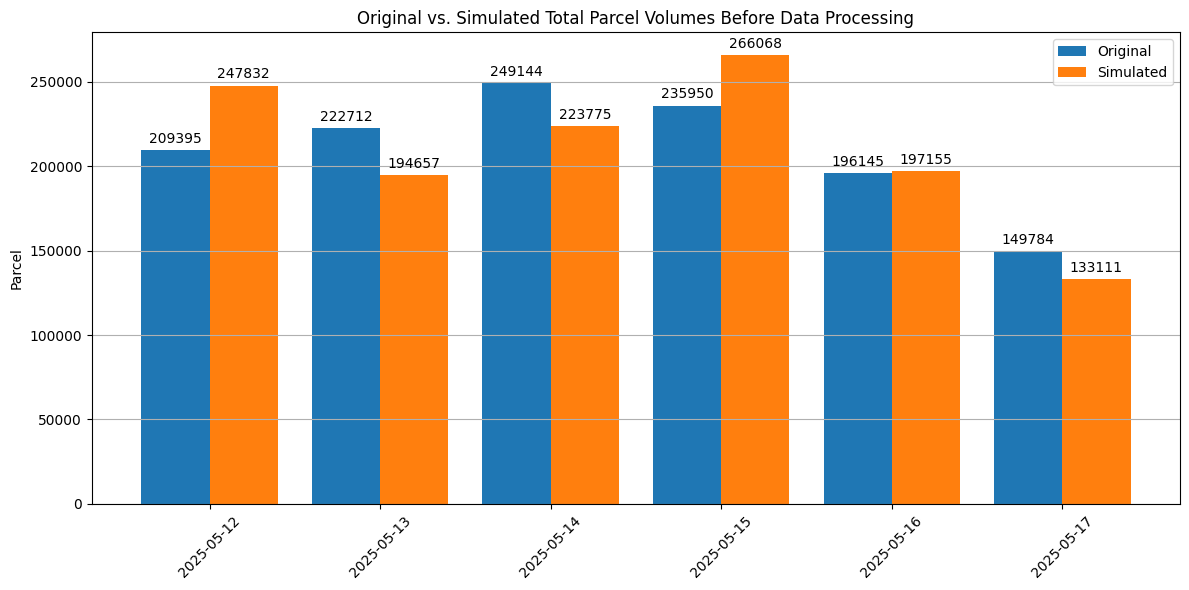

2025-09-01 11:01:19,138 - INFO - Initializing lookup_coords for new_week...
2025-09-01 11:01:34,710 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-09-01 11:01:34,721 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=5038, B2C=9024
2025-09-01 11:01:40,862 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-09-01 11:01:40,883 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=819, B2C=2022
2025-09-01 11:01:42,180 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:01:42,198 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=624, B2C=1559
2025-09-01 11:01:43,201 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:01:43,220 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=9936, B2C=544
2025-09-01 11:01:45,740 - INFO - ✅ Valid

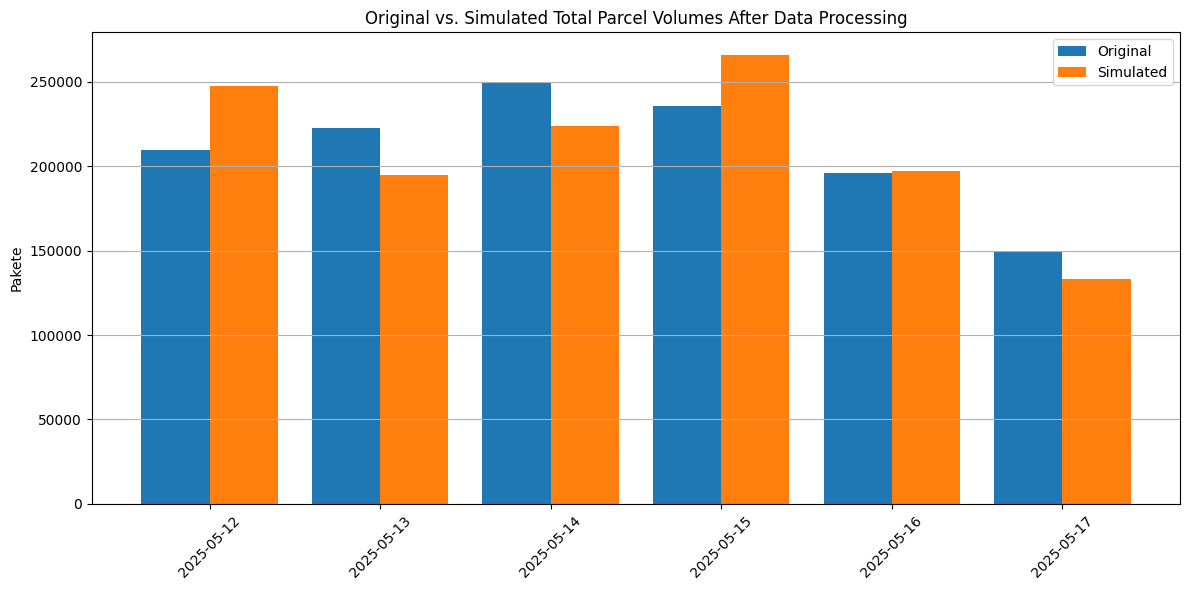

2025-09-01 11:03:01,853 - INFO - ✅ Finished distributing results into new_week
2025-09-01 11:03:01,865 - INFO - Finished simulation for scenario: moderate_cost


In [49]:
new_moderate_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='moderate_cost')

2025-09-01 11:03:01,967 - INFO - ================================================================================
2025-09-01 11:03:01,967 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: MEDIUM_COST
2025-09-01 11:03:01,967 - INFO - ================================================================================
2025-09-01 11:03:02,020 - INFO - Loaded and initialized data for Monday.
2025-09-01 11:03:02,027 - INFO - Loaded and initialized data for Tuesday.
2025-09-01 11:03:02,034 - INFO - Loaded and initialized data for Wednesday.
2025-09-01 11:03:02,042 - INFO - Loaded and initialized data for Thursday.
2025-09-01 11:03:02,048 - INFO - Loaded and initialized data for Friday.
2025-09-01 11:03:02,054 - INFO - Loaded and initialized data for Saturday.
2025-09-01 11:03:02,054 - INFO - ============================================================
2025-09-01 11:03:02,055 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-09-01 11:03:02,055 - INFO - ===================================

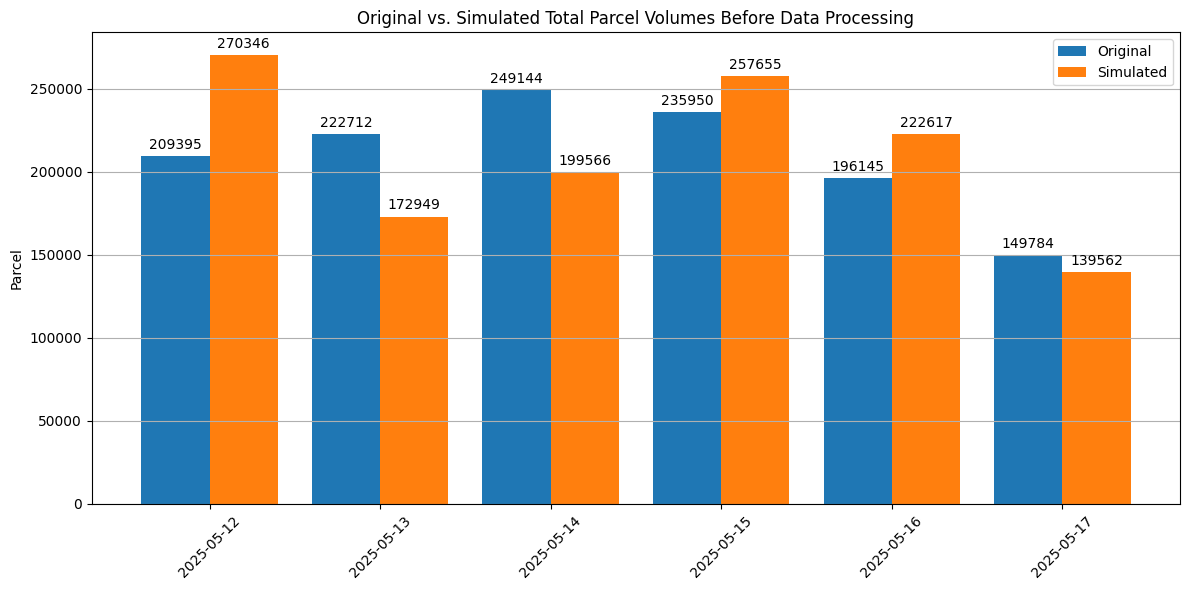

2025-09-01 11:03:02,718 - INFO - Initializing lookup_coords for new_week...
2025-09-01 11:03:18,420 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-09-01 11:03:18,431 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7045, B2C=42486
2025-09-01 11:03:37,602 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-09-01 11:03:37,625 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1149, B2C=9489
2025-09-01 11:03:40,243 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:03:40,261 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=874, B2C=7249
2025-09-01 11:03:42,136 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:03:42,153 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=13901, B2C=2574
2025-09-01 11:03:45,416 - INFO - ✅ V

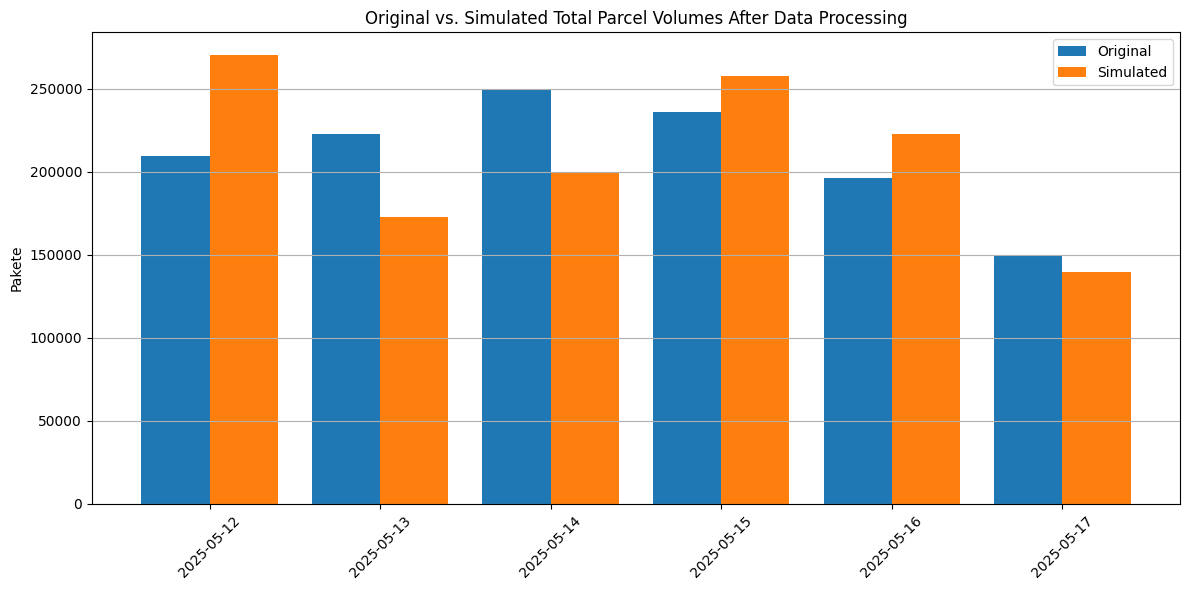

2025-09-01 11:06:59,527 - INFO - ✅ Finished distributing results into new_week
2025-09-01 11:06:59,538 - INFO - Finished simulation for scenario: medium_cost


In [50]:
new_medium_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='medium_cost')

2025-09-01 11:06:59,652 - INFO - ================================================================================
2025-09-01 11:06:59,652 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: HIGH_COST
2025-09-01 11:06:59,653 - INFO - ================================================================================
2025-09-01 11:06:59,704 - INFO - Loaded and initialized data for Monday.
2025-09-01 11:06:59,711 - INFO - Loaded and initialized data for Tuesday.
2025-09-01 11:06:59,717 - INFO - Loaded and initialized data for Wednesday.
2025-09-01 11:06:59,724 - INFO - Loaded and initialized data for Thursday.
2025-09-01 11:06:59,731 - INFO - Loaded and initialized data for Friday.
2025-09-01 11:06:59,737 - INFO - Loaded and initialized data for Saturday.
2025-09-01 11:06:59,737 - INFO - ============================================================
2025-09-01 11:06:59,738 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-09-01 11:06:59,738 - INFO - =====================================

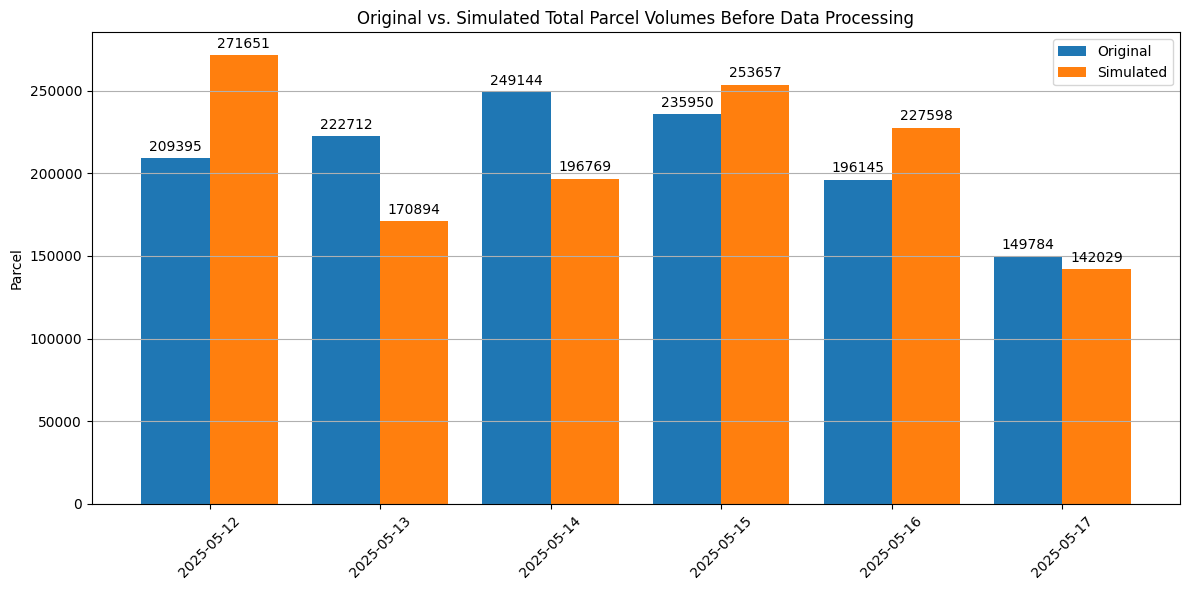

2025-09-01 11:07:00,401 - INFO - Initializing lookup_coords for new_week...
2025-09-01 11:07:15,997 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-09-01 11:07:16,008 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7045, B2C=48199
2025-09-01 11:07:36,853 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-09-01 11:07:36,876 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1149, B2C=10812
2025-09-01 11:07:39,625 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:07:39,642 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=874, B2C=8244
2025-09-01 11:07:41,645 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:07:41,662 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=13903, B2C=2919
2025-09-01 11:07:44,913 - INFO - ✅ 

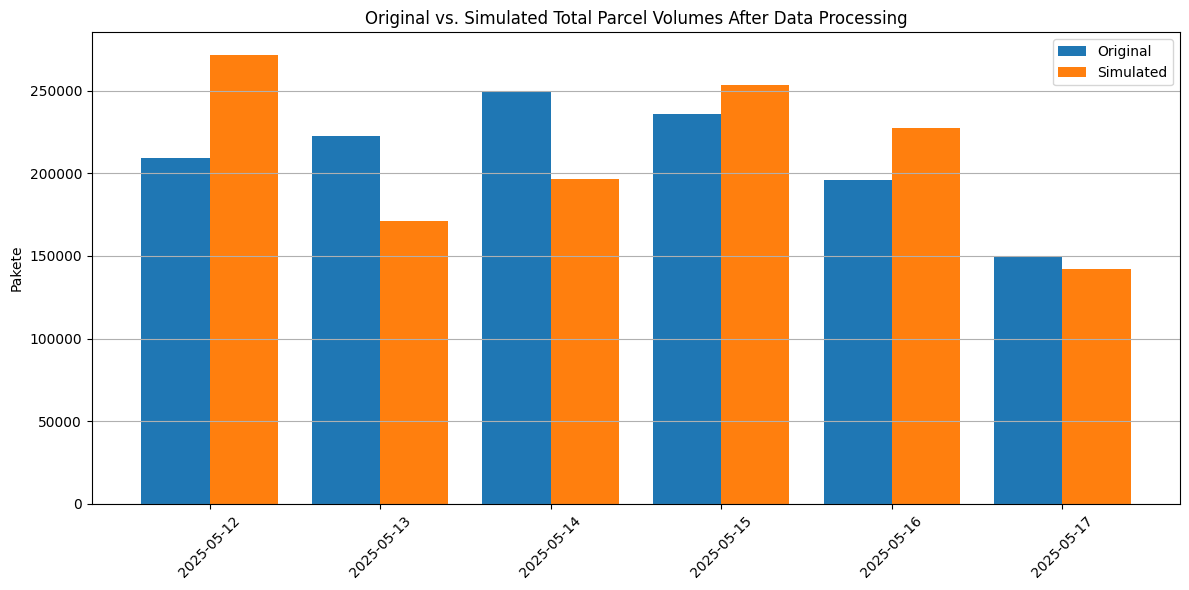

2025-09-01 11:11:11,461 - INFO - ✅ Finished distributing results into new_week
2025-09-01 11:11:11,471 - INFO - Finished simulation for scenario: high_cost


In [51]:
new_high_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='high_cost')

2025-09-01 11:11:11,577 - INFO - ================================================================================
2025-09-01 11:11:11,577 - INFO - STARTING WEEKLY SIMULATION FOR SCENARIO: FULL_SCENARIO
2025-09-01 11:11:11,578 - INFO - ================================================================================
2025-09-01 11:11:11,628 - INFO - Loaded and initialized data for Monday.
2025-09-01 11:11:11,635 - INFO - Loaded and initialized data for Tuesday.
2025-09-01 11:11:11,642 - INFO - Loaded and initialized data for Wednesday.
2025-09-01 11:11:11,649 - INFO - Loaded and initialized data for Thursday.
2025-09-01 11:11:11,655 - INFO - Loaded and initialized data for Friday.
2025-09-01 11:11:11,661 - INFO - Loaded and initialized data for Saturday.
2025-09-01 11:11:11,661 - INFO - ============================================================
2025-09-01 11:11:11,662 - INFO -  *** START BATCH SIMULATION FOR: MONDAY *** 
2025-09-01 11:11:11,662 - INFO - =================================

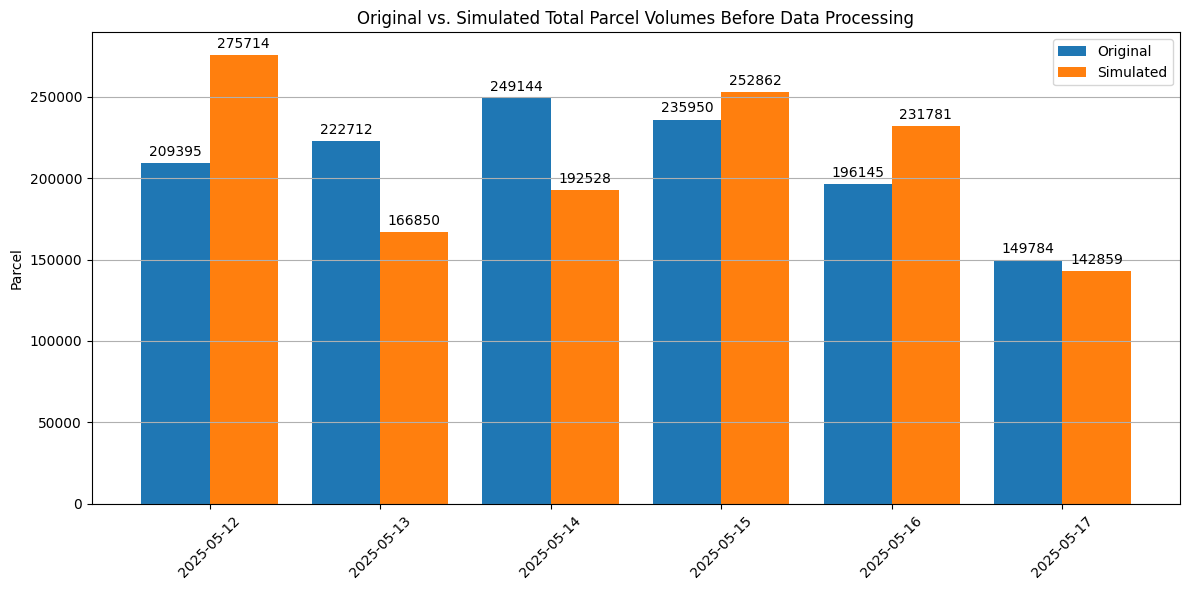

2025-09-01 11:11:12,319 - INFO - Initializing lookup_coords for new_week...
2025-09-01 11:11:27,892 - INFO - Lookup_coords initialized. Loaded 404030 geometries.
2025-09-01 11:11:27,903 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for DHL: B2B=7402, B2C=53803
2025-09-01 11:11:49,616 - INFO - ✅ Validation passed for DHL: totals consistent from None → Monday
2025-09-01 11:11:49,639 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for GLS: B2B=1202, B2C=12048
2025-09-01 11:11:52,578 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:11:52,594 - INFO - → Transfer from 2025-05-10 (outside week) to 2025-05-12 (Monday) for GLS: B2B=911, B2C=9196
2025-09-01 11:11:54,722 - INFO - ✅ Validation passed for GLS: totals consistent from None → Monday
2025-09-01 11:11:54,738 - INFO - → Transfer from 2025-05-09 (outside week) to 2025-05-12 (Monday) for UPS: B2B=14649, B2C=3281
2025-09-01 11:11:58,155 - INFO - ✅ 

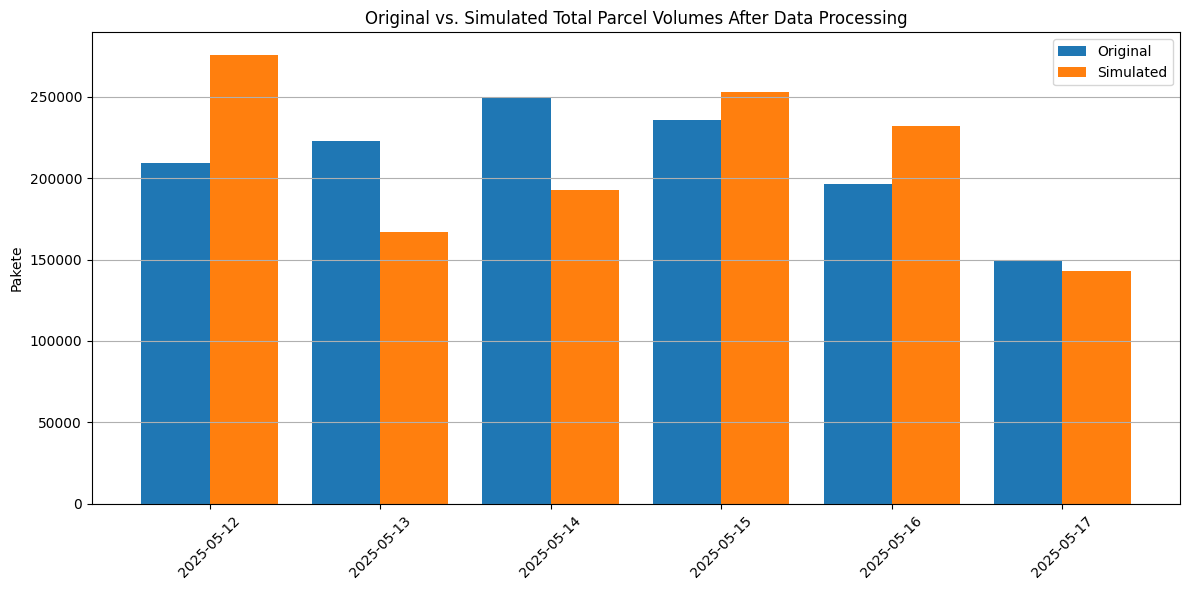

2025-09-01 11:15:40,547 - INFO - ✅ Finished distributing results into new_week
2025-09-01 11:15:40,557 - INFO - Finished simulation for scenario: full_scenario


In [52]:
new_full_week = simulate_full_existing_week(deepcopy(hagrid_files), days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], start_date = datetime.date(2025, 5, 12), scenario='full_scenario')

In [53]:
def prepare_old_week(hagrid_files_thisweek, days, base_date):
    """
    Prepares the old (original) week from hagrid_files without simulation changes.
    Calculates wl_tag and total fields.
    """
    old_week = {}

    for i, day in enumerate(days):
        date_str = (base_date + datetime.timedelta(days=i)).strftime("%Y-%m-%d")
        key = f"hagrid_parcel_demand_{date_str}_({day})"
        if key not in hagrid_files_thisweek:
            raise KeyError(f"Missing file for {key}.")
        
        df = hagrid_files_thisweek[key].copy() 

        old_week[day] = df

    return old_week

def plot_wltag_comparison(old_week, new_week, old_label="Old Week", new_label="New Week"):
    """
    Plots the total wl_tag per day for old and new weeks for comparison.
    """
    days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']
    
    old_totals = []
    new_totals = []

    for day in days:
        old_df = old_week.get(day)
        new_df = new_week.get(day)

        if old_df is not None:
            old_total = old_df['wl_tag'].sum()
        else:
            old_total = 0

        if new_df is not None:
            new_total = new_df['wl_tag'].sum()
        else:
            new_total = 0

        old_totals.append(old_total)
        new_totals.append(new_total)

    for carrier in carrier_columns:
        prefix, _, _ = carrier_columns[carrier]
        old_sum = old_week['Tuesday'][f"{prefix}_b2b"].sum() + old_week['Tuesday'][f"{prefix}_b2c"].sum()
        new_sum = new_week['Tuesday'][f"{prefix}_b2b"].sum() + new_week['Tuesday'][f"{prefix}_b2c"].sum()
        print(f"Tuesday {carrier}: old={old_sum}, new={new_sum}")

    # Plot
    plt.figure(figsize=(10, 6))
    plt.plot(days, old_totals, marker='o', label=old_label)
    plt.plot(days, new_totals, marker='o', label=new_label)

    plt.title("Comparison of wl_tag Totals per Day", fontsize=14)
    plt.xlabel("Day of Week", fontsize=12)
    plt.ylabel("Total wl_tag (Deliveries)", fontsize=12)
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.7)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

old_week = prepare_old_week(hagrid_files, days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday'], base_date = datetime.date(2025, 5, 12))

old_week


{'Monday':       str_idx                name postal_cod  cell_id  total_sim  ama_b2b  \
 0           0    Aegidienkirchhof      30159   8611.0          7        0   
 1           0    Aegidienkirchhof      30159   8611.0          5        0   
 2           1     Alexanderstraße      30159   9181.0          8        0   
 3           1     Alexanderstraße      30159   9181.0          2        0   
 4           2       Am Hohen Ufer      30159   8613.0          5        0   
 ...       ...                 ...        ...      ...        ...      ...   
 67746   12340      Ziegeleistraße      30855   7431.0          7        0   
 67747   12340      Ziegeleistraße      30855   7431.0         12        0   
 67748   12340      Ziegeleistraße      30855   7061.0          6        0   
 67749   12340      Ziegeleistraße      30855   7061.0          3        0   
 67750   12341  Zur Schnittenriede      30855   9347.0          2        0   
 
        ama_b2c  dhl_b2b  dhl_b2c  dpd_b2b  ...  fed

In [57]:
import numpy as np
import pandas as pd
import logging
from typing import Dict, Tuple

def _flow_cols(df: pd.DataFrame) -> list:
    return [c for c in df.columns if c.endswith("_b2b") or c.endswith("_b2c")]

def apply_type_tag_and_totals_no_rename(
    new_week: Dict[str, pd.DataFrame],
    carrier_columns: Dict[str, Tuple[str, str, str]],
    logger: logging.Logger | None = None,
    scenario_name: str = "unknown"
) -> Dict[str, pd.DataFrame]:
    """
    Do not change column names.
    For each provider:
      copy <prefix>_b2b -> type_col      (from carrier_columns)
      copy <prefix>_b2c -> tag_col       (from carrier_columns)
    Then set:
      wl_tag   = row sum over all tag and type columns
      total_sim= row sum over all *_b2b and *_b2c
      total    = total_sim
    Assertions per day:
      sum(all *_b2b) == sum(all type cols)
      sum(all *_b2c) == sum(all tag cols)
      sum(wl_tag) == sum(all flows) == sum(total_sim) == sum(total)
      no NaN and no negatives in flows, tag, type, totals
      integer values or floats that are integer valued
    Operates on copies and returns modified dict.
    """
    log = logger if logger is not None else logging.getLogger(__name__)

    for day, df in new_week.items():
        log.info("Start edit for scenario=%s | day=%s", scenario_name, day)
        if not isinstance(df, pd.DataFrame):
            raise TypeError(f"{scenario_name} {day}: input is not a DataFrame")

        df = df.copy()

        # 1) copy flows into existing tag/type columns as given in carrier_columns
        b2b_cols = []
        b2c_cols = []
        type_cols = []
        tag_cols = []

        for provider, (prefix, tag_col, type_col) in carrier_columns.items():
            src_b2b = f"{prefix}_b2b"
            src_b2c = f"{prefix}_b2c"

            if src_b2b in df.columns:
                df[type_col] = df[src_b2b].fillna(0).astype(int)
                b2b_cols.append(src_b2b)
                type_cols.append(type_col)
            else:
                log.info("[%s|%s] missing column %s for type copy", scenario_name, day, src_b2b)

            if src_b2c in df.columns:
                df[tag_col] = df[src_b2c].fillna(0).astype(int)
                b2c_cols.append(src_b2c)
                tag_cols.append(tag_col)
            else:
                log.info("[%s|%s] missing column %s for tag copy", scenario_name, day, src_b2c)

        # 2) immediate checks for copy correctness
        b2b_sum = int(df[b2b_cols].sum().sum()) if b2b_cols else 0
        type_sum = int(df[type_cols].sum().sum()) if type_cols else 0
        if b2b_sum != type_sum:
            raise AssertionError(f"{scenario_name} {day}: sum(b2b) {b2b_sum} != sum(type) {type_sum}")

        b2c_sum = int(df[b2c_cols].sum().sum()) if b2c_cols else 0
        tag_sum = int(df[tag_cols].sum().sum()) if tag_cols else 0
        if b2c_sum != tag_sum:
            raise AssertionError(f"{scenario_name} {day}: sum(b2c) {b2c_sum} != sum(tag) {tag_sum}")

        # 3) totals
        flow_cols = _flow_cols(df)
        df["total_sim"] = df[flow_cols].sum(axis=1) if flow_cols else 0
        df["total"] = df["total_sim"]
        all_type_tag = tag_cols + type_cols
        df["wl_tag"] = df[all_type_tag].sum(axis=1) if all_type_tag else 0

        # 4) grand total checks
        flows_total = int(df[flow_cols].sum().sum()) if flow_cols else 0
        wl_tag_total = int(df["wl_tag"].sum()) if "wl_tag" in df.columns else 0
        total_sim_total = int(df["total_sim"].sum()) if "total_sim" in df.columns else 0
        total_total = int(df["total"].sum()) if "total" in df.columns else 0

        if not (flows_total == wl_tag_total == total_sim_total == total_total):
            raise AssertionError(
                f"{scenario_name} {day}: mismatch totals flows={flows_total} wl_tag={wl_tag_total} total_sim={total_sim_total} total={total_total}"
            )

        # 5) quality checks
        cols_check = flow_cols + all_type_tag + ["total_sim", "total", "wl_tag"]
        if cols_check:
            if df[cols_check].isna().any().any():
                raise AssertionError(f"{scenario_name} {day}: NaN detected in {cols_check}")
            if (df[cols_check] < 0).any().any():
                raise AssertionError(f"{scenario_name} {day}: negative values detected in {cols_check}")
            # integerish check
            non_integer_cols = []
            for c in cols_check:
                if not np.issubdtype(df[c].dtype, np.integer):
                    if not np.isclose(df[c] % 1, 0).all():
                        non_integer_cols.append(c)
            if non_integer_cols:
                raise AssertionError(f"{scenario_name} {day}: non integer values in {non_integer_cols}")

        new_week[day] = df
        log.info("Finished edit for scenario=%s | day=%s totals=%d", scenario_name, day, total_total)

    return new_week

scenarios = {
    "full": new_full_week,
    "high": new_high_week,
    "medium": new_medium_week,
    "moderate": new_moderate_week,
}

for name, week in scenarios.items():
    scenarios[name] = apply_type_tag_and_totals_no_rename(
        new_week=week,
        carrier_columns=carrier_columns,
        logger=LOGGER,
        scenario_name=name
    )
    LOGGER.info("Edit completed for scenario %s", name)

# optional zurückschreiben
new_full_week = scenarios["full"]
new_high_week = scenarios["high"]
new_medium_week = scenarios["medium"]
new_moderate_week = scenarios["moderate"]



2025-09-01 11:24:41,190 - INFO - Start edit for scenario=full | day=Monday
2025-09-01 11:24:41,299 - INFO - Finished edit for scenario=full | day=Monday totals=275714
2025-09-01 11:24:41,304 - INFO - Start edit for scenario=full | day=Tuesday
2025-09-01 11:24:41,409 - INFO - Finished edit for scenario=full | day=Tuesday totals=166850
2025-09-01 11:24:41,413 - INFO - Start edit for scenario=full | day=Wednesday
2025-09-01 11:24:41,530 - INFO - Finished edit for scenario=full | day=Wednesday totals=192528
2025-09-01 11:24:41,534 - INFO - Start edit for scenario=full | day=Thursday
2025-09-01 11:24:41,650 - INFO - Finished edit for scenario=full | day=Thursday totals=252862
2025-09-01 11:24:41,654 - INFO - Start edit for scenario=full | day=Friday
2025-09-01 11:24:41,765 - INFO - Finished edit for scenario=full | day=Friday totals=231781
2025-09-01 11:24:41,770 - INFO - Start edit for scenario=full | day=Saturday
2025-09-01 11:24:41,869 - INFO - Finished edit for scenario=full | day=Satur

In [63]:
new_moderate_week.get("Monday")["amazon_typ"].sum()

np.int64(91)

In [64]:
import os
import logging
from typing import Dict, Iterable, Tuple
import geopandas as gpd
from shapely.geometry.base import BaseGeometry

# ----------------------------------------------------------------------
# Logging setup
# ----------------------------------------------------------------------
if not logging.getLogger().handlers:
    logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(message)s")

# ----------------------------------------------------------------------
# Helpers
# ----------------------------------------------------------------------
def _normalize_gdf(df: gpd.GeoDataFrame) -> gpd.GeoDataFrame:
    """
    Ensure a consistent geometry and CRS.
    - Use 'point_geom' as active geometry if present, otherwise keep current geometry.
    - Set CRS to EPSG:25832 if missing.
    - Drop any extra geometry-like columns other than the active one.
    """
    if "point_geom" in df.columns:
        z = df.set_geometry("point_geom").copy()
    else:
        z = df.copy()
        if z.geometry.name is None:
            raise ValueError("No active geometry set and no 'point_geom' column available.")

    # Set CRS to EPSG:25832 if missing
    if z.crs is None:
        logging.warning("No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.")
        z.set_crs("EPSG:25832", inplace=True, allow_override=True)

    # Drop any other geometry-like columns
    for col in list(z.columns):
        if col == z.geometry.name:
            continue
        if len(z) > 0:
            first = z[col].iloc[0]
            if isinstance(first, BaseGeometry):
                z = z.drop(columns=[col])

    return z

def export_gdf(df: gpd.GeoDataFrame, out_path: str, driver: str):
    """
    Export a GeoDataFrame directly to a file with the given driver.
    Ensures CRS and geometry, logs what is written where.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    z = _normalize_gdf(df)
    logging.info("Writing %s to %s", driver, out_path)
    z.to_file(out_path, driver=driver)

def export_csv(df: gpd.GeoDataFrame, out_path: str):
    """
    Export a GeoDataFrame to CSV with geometry as WKT.
    Ensures CRS and geometry for a consistent WKT export, logs destination.
    """
    os.makedirs(os.path.dirname(out_path), exist_ok=True)
    z = _normalize_gdf(df)
    df_csv = z.copy()
    df_csv["geometry"] = df_csv.geometry.apply(lambda g: g.wkt if g is not None else None)
    logging.info("Writing CSV to %s", out_path)
    df_csv.to_csv(out_path, index=False)




def _num_series(s: pd.Series) -> pd.Series:
    """Convert a Series to numeric with NaN to 0."""
    return pd.to_numeric(s, errors="coerce").fillna(0)


# ----------------------------------------------------------------------
# Formats and main loop
# ----------------------------------------------------------------------
formats = {
    "shp":  ("ESRI Shapefile", ".shp"),
    "gpkg": ("GPKG", ".gpkg"),
    "geojson": ("GeoJSON", ".geojson"),
}

scenarios = [
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week),
]

weekday_name_map = {
    "Monday":    "hagrid_parcel_demand_2025-05-12_(Monday)",
    "Tuesday":   "hagrid_parcel_demand_2025-05-13_(Tuesday)",
    "Wednesday": "hagrid_parcel_demand_2025-05-14_(Wednesday)",
    "Thursday":  "hagrid_parcel_demand_2025-05-15_(Thursday)",
    "Friday":    "hagrid_parcel_demand_2025-05-16_(Friday)",
    "Saturday":  "hagrid_parcel_demand_2025-05-17_(Saturday)",
}



for scenario_name, week_dict in scenarios:
    scenario_dir = os.path.join("output", "batchdelivery", scenario_name)
    os.makedirs(scenario_dir, exist_ok=True)
    logging.info("Exporting scenario '%s' into %s", scenario_name, scenario_dir)

    for weekday, gdf in week_dict.items():
        if weekday not in weekday_name_map:
            logging.warning("Weekday '%s' not in weekday_name_map. Skipping.", weekday)
            continue

        stem = weekday_name_map[weekday]  # keep exact filename stem
        # Geo formats
        for _, (driver, ext) in formats.items():
            out_path = os.path.join(scenario_dir, stem + ext)
            export_gdf(gdf, out_path, driver=driver)

        # CSV
        csv_path = os.path.join(scenario_dir, stem + ".csv")
        export_csv(gdf, csv_path)


2025-09-01 11:30:33,284 - INFO - Exporting scenario 'Moderate Cost' into output\batchdelivery\Moderate Cost
2025-09-01 11:30:33,308 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-09-01 11:30:33,311 - INFO - Writing ESRI Shapefile to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).shp
2025-09-01 11:30:35,173 - INFO - Created 78,029 records
2025-09-01 11:30:35,196 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-09-01 11:30:35,198 - INFO - Writing GPKG to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).gpkg
2025-09-01 11:30:36,193 - INFO - Created 78,029 records
2025-09-01 11:30:36,323 - WARNING - No CRS found on GeoDataFrame. Setting CRS to EPSG:25832.
2025-09-01 11:30:36,325 - INFO - Writing GeoJSON to output\batchdelivery\Moderate Cost\hagrid_parcel_demand_2025-05-12_(Monday).geojson
2025-09-01 11:30:39,224 - INFO - Created 78,029 records
2025-09-01 11:30:39,246 - WARNING - No C

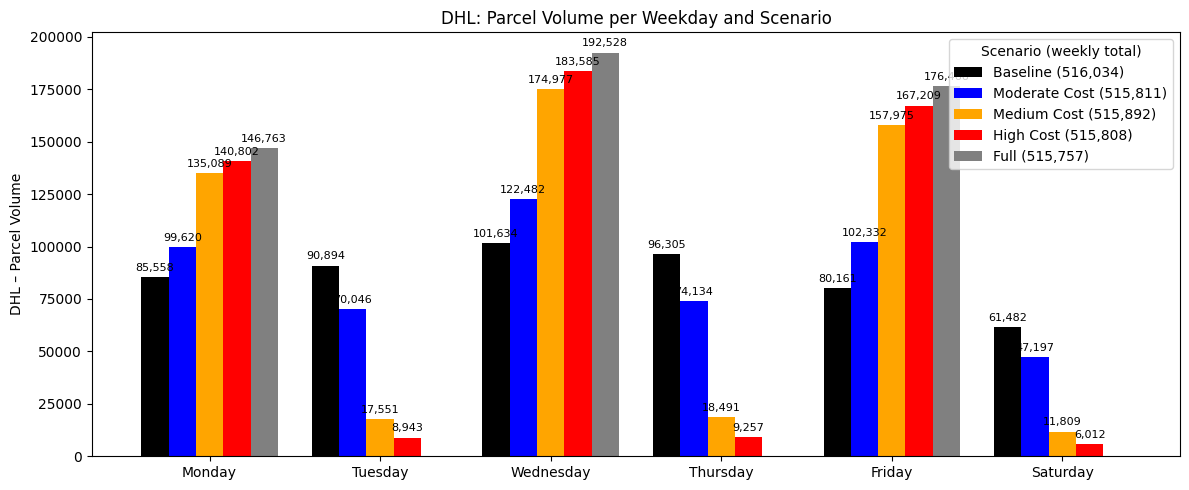

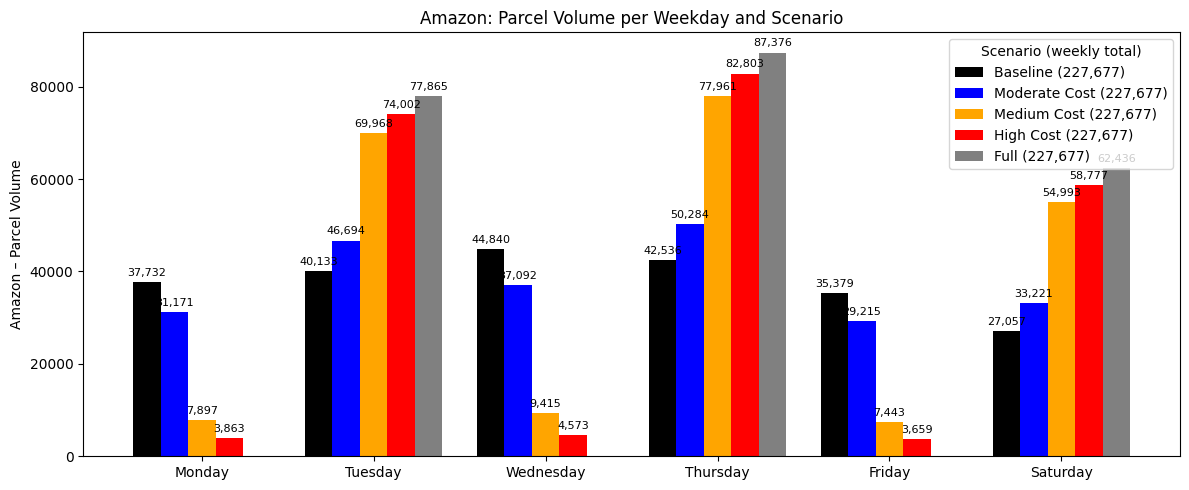

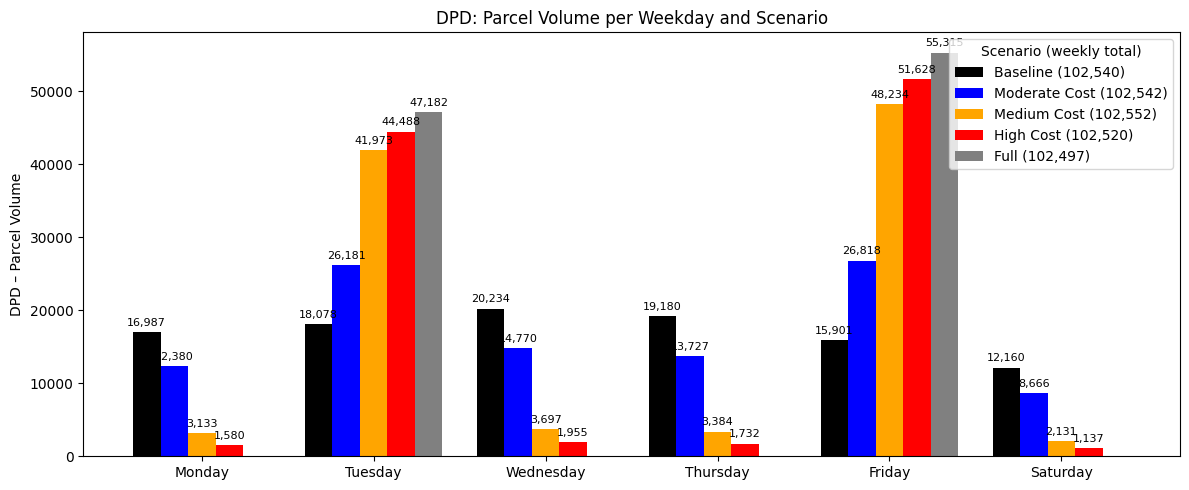

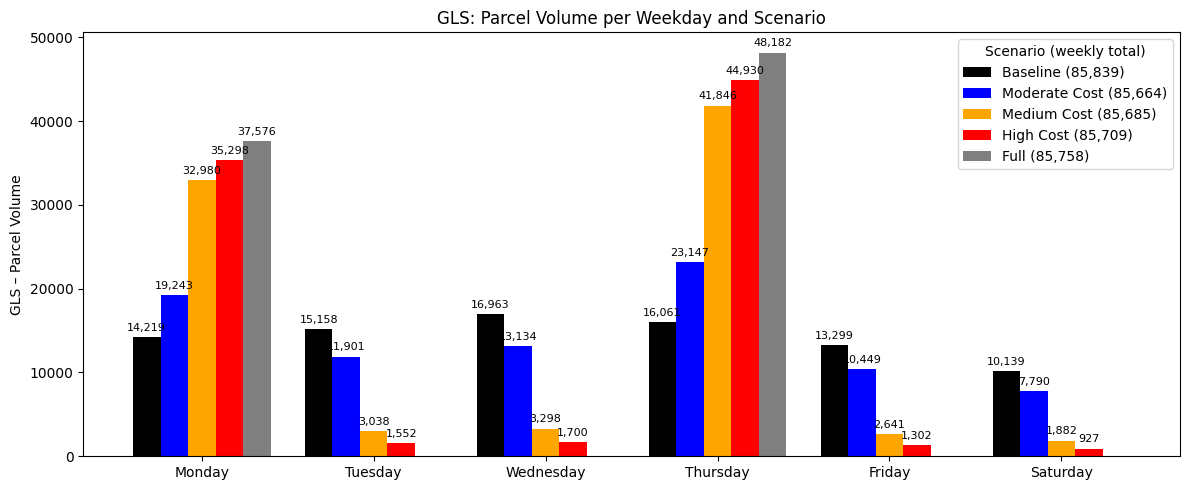

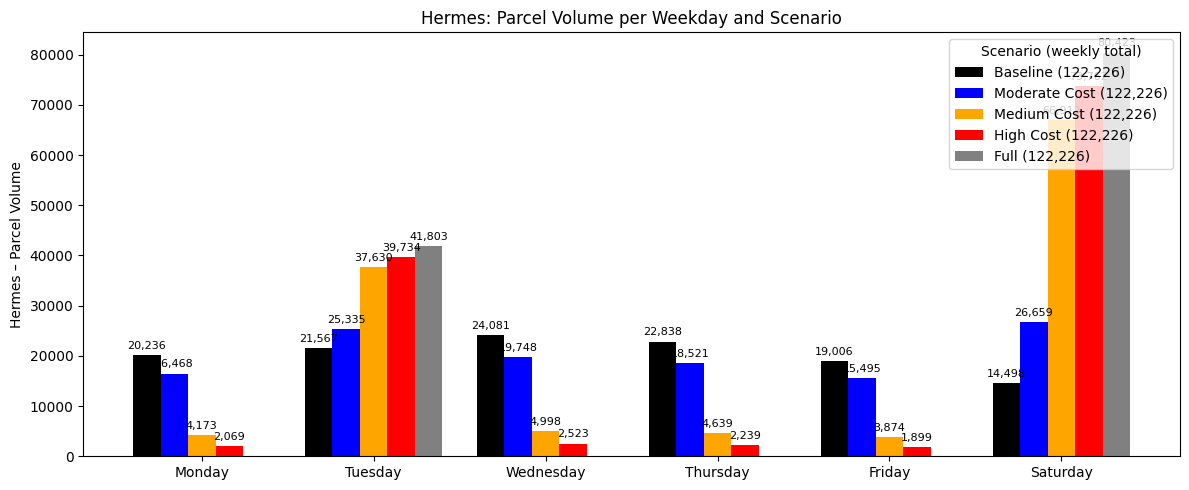

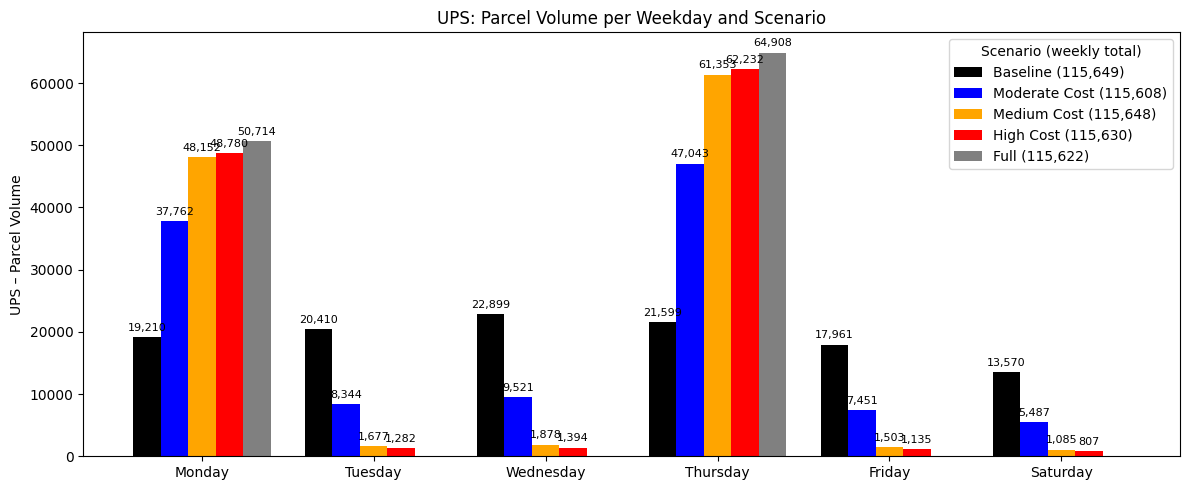

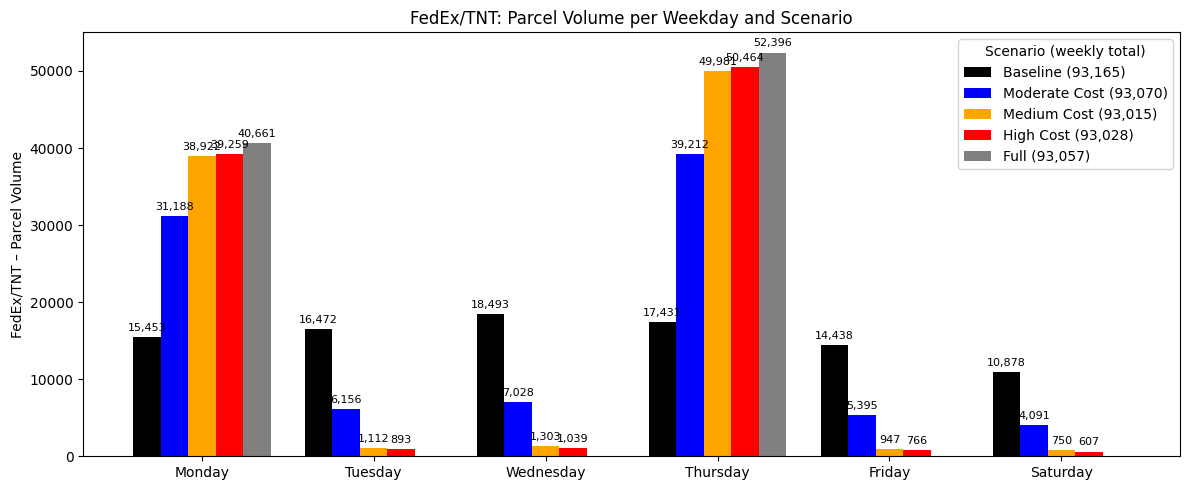

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Szenarien definieren
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week)
]

# Farben definieren
colors = {
    "Baseline": "black",
    "Moderate Cost": "blue",
    "Medium Cost": "orange",
    "High Cost": "red",
    "Full": "grey"
}

# Wochentage
weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
day_map = {day: i for i, day in enumerate(weekdays)}

# Paketdienstleister
carriers = {
    "DHL": ("dhl_b2b", "dhl_b2c"),
    "Amazon": ("ama_b2b", "ama_b2c"),
    "DPD": ("dpd_b2b", "dpd_b2c"),
    "GLS": ("gls_b2b", "gls_b2c"),
    "Hermes": ("her_b2b", "her_b2c"),
    "UPS": ("ups_b2b", "ups_b2c"),
    "FedEx/TNT": ("fxt_b2b", "fxt_b2c")
}

# Plot pro Carrier
for carrier, (col_b2b, col_b2c) in carriers.items():
    records = []
    total_per_scenario = {}
    
    for scen_name, weekdict in scenarios:
        week_total = 0
        for day in weekdays:
            gdf = weekdict.get(day)
            if gdf is not None and col_b2b in gdf.columns and col_b2c in gdf.columns:
                total = gdf[col_b2b].sum() + gdf[col_b2c].sum()
                records.append({'Scenario': scen_name, 'Day': day, 'Total': total})
                week_total += total
        total_per_scenario[scen_name] = week_total

    df = pd.DataFrame(records)
    
    if df.empty:
        print(f"Skipping {carrier} – no data.")
        continue

    df["Day_idx"] = df["Day"].map(day_map)

    # Plot
    fig, ax = plt.subplots(figsize=(12, 5))
    bar_width = 0.16
    x = np.arange(len(weekdays))
    offsets = [-2, -1, 0, 1, 2]

    for (scenario, _), offset in zip(scenarios, offsets):
        df_scen = df[df["Scenario"] == scenario].sort_values("Day_idx")
        bars = ax.bar(x + offset * bar_width, df_scen["Total"], width=bar_width,
                      label=f"{scenario} ({int(total_per_scenario[scenario]):,})",
                      color=colors[scenario])

        # Annotate bars
        for bar in bars:
            height = bar.get_height()
            if height > 0:
                ax.annotate(f'{int(height):,}',
                            xy=(bar.get_x() + bar.get_width() / 2, height),
                            xytext=(0, 3),
                            textcoords="offset points",
                            ha='center', va='bottom', fontsize=8)

    ax.set_xticks(x)
    ax.set_xticklabels(weekdays)
    ax.set_ylabel(f"{carrier} – Parcel Volume")
    ax.set_title(f"{carrier}: Parcel Volume per Weekday and Scenario")
    ax.legend(title="Scenario (weekly total)", loc="upper right")
    plt.tight_layout()
    plt.show()


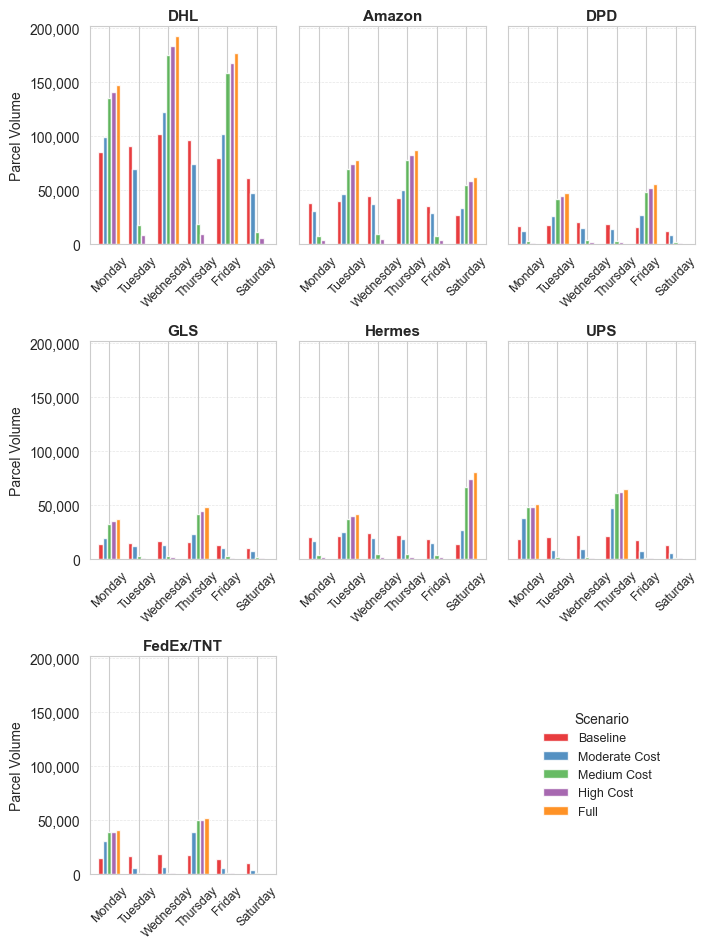

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from matplotlib.ticker import FuncFormatter

def thousands_us(x, pos):
    return f"{int(x):,}"

plt.style.use("default")
sns.set_style("whitegrid")

# Liste der LSPs aus carrier_columns (dein bestehendes Mapping)
selected_lsps = ["DHL", "Amazon", "DPD", "GLS", "Hermes", "UPS", "FedEx/TNT"]
carrier_columns = {
    "Amazon": ('ama', 'amazon_tag', 'amazon_typ'),
    "DHL": ('dhl', 'dhl_tag', 'dhl_type'),
    "DPD": ('dpd', 'dpd_tag', 'dpd_type'),
    "GLS": ('gls', 'gls_tag', 'gls_type'),
    "Hermes": ('her', 'hermes_tag', 'hermes_typ'),
    "UPS": ('ups', 'ups_tag', 'ups_type'),
    "FedEx/TNT": ('fxt', 'fedex_tag', 'fedex_type')
}

# Szenarien
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week)
]

colors = {
    "Baseline": "black",
    "Moderate Cost": "blue",
    "Medium Cost": "orange",
    "High Cost": "red",
    "Full": "grey"
}

weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]

# Datensammlung für alle Carrier
records = []
for scen_name, weekdict in scenarios:
    for carrier in selected_lsps:
        prefix = carrier_columns[carrier][0]
        for day in weekdays:
            gdf = weekdict.get(day)
            if gdf is not None:
                total = gdf[f"{prefix}_b2b"].sum() + gdf[f"{prefix}_b2c"].sum()
                records.append({
                    "Carrier": carrier,
                    "Scenario": scen_name,
                    "Day": day,
                    "Total": total
                })

df = pd.DataFrame(records)

scenario_order = ['Baseline', 'Moderate Cost', 'Medium Cost', 'High Cost', 'Full']
selected_lsps = ['DHL', 'Amazon', 'DPD', 'GLS', 'Hermes', 'UPS', 'FedEx/TNT']
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday']

palette = sns.color_palette("Set1", len(scenario_order))
colors = dict(zip(scenario_order, palette))

df["Day"] = pd.Categorical(df["Day"], categories=day_order, ordered=True)
df["Scenario"] = pd.Categorical(df["Scenario"], categories=scenario_order, ordered=True)
df = df.sort_values(["Carrier", "Day", "Scenario"])

n = len(selected_lsps)
cols = 3
rows = int(np.ceil((n + 1) / cols))  # +1 für Legende
bar_width = 0.15
x = np.arange(len(day_order))
offsets = np.linspace(-2, 2, num=len(scenario_order)) * bar_width

fig, axes = plt.subplots(rows, cols, figsize=(7.2, 9.6), sharey=True)
axes = axes.flatten()

for i, carrier in enumerate(selected_lsps):
    ax = axes[i]
    df_c = df[df["Carrier"] == carrier]

    for j, scenario in enumerate(scenario_order):
        df_scen = df_c[df_c["Scenario"] == scenario].sort_values("Day")
        ax.bar(x + offsets[j], df_scen["Total"], width=bar_width,
               label=scenario if i == 0 else "", color=colors[scenario], alpha=0.85)

    ax.set_title(carrier, fontsize=11, fontweight="bold", pad=4)
    ax.set_xticks(x)
    ax.set_xticklabels(day_order, rotation=45, fontsize=9)
    ax.grid(axis="y", linestyle="--", linewidth=0.5, alpha=0.5)
    ax.yaxis.set_major_formatter(FuncFormatter(thousands_us))

    if i % cols == 0:
        ax.set_ylabel("Parcel Volume", fontsize=10)

# Legendenachse mittig platzieren (mittleres Feld der unteren Reihe)
legend_ax_index = len(selected_lsps)
middle_col = 2  # Spalte 2 (nullbasiert)
middle_row = rows - 1
middle_index = middle_row * cols + middle_col

legend_ax = axes[middle_index]
legend_ax.axis("off")

handles, labels = axes[0].get_legend_handles_labels()
legend_ax.legend(handles, labels, title="Scenario",
                 loc="center", fontsize=9, title_fontsize=10, frameon=False)

# Alle weiteren ungenutzten Achsen ausblenden
for j in range(len(selected_lsps), len(axes)):
    if j != middle_index:
        fig.delaxes(axes[j])

plt.tight_layout()
plt.show()


C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_40800\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:25832

  joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_40800\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:25832

  joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
C:\Users\bienzeisler\AppData\Local\Temp\ipykernel_40800\3219225065.py:47: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS

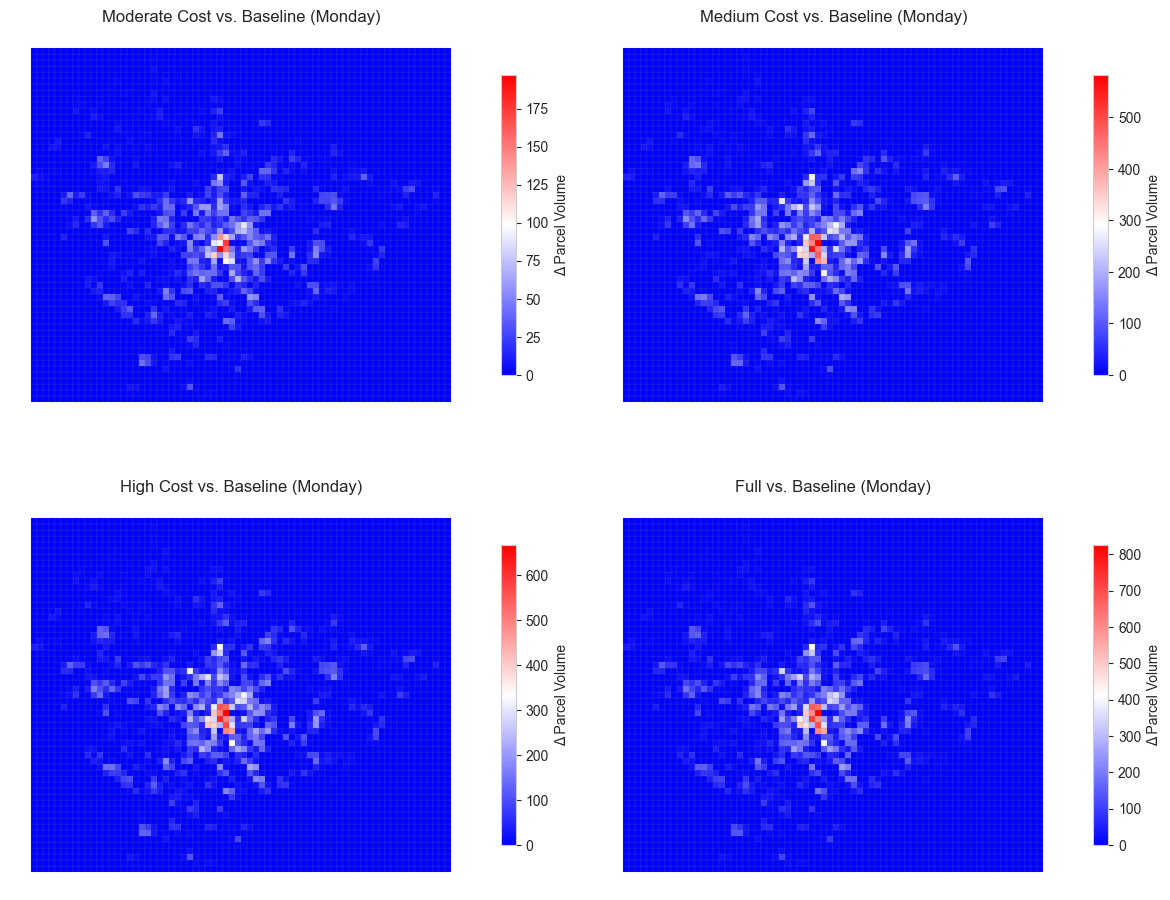

In [15]:
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from shapely.geometry import box

# 1. Grundlage: Montag aus Baseline (old_week)
gdf_base = old_week["Monday"].copy()
gdf_base["Total"] = gdf_base["dhl_b2b"] + gdf_base["dhl_b2c"]
gdf_base = gdf_base[gdf_base["Total"] > 0].copy()

# 2. Rasterdefinition (500 × 500 m)
cell_size = 1000  # in meters
bbox = gdf_base.total_bounds  # [minx, miny, maxx, maxy]
xmin, ymin, xmax, ymax = bbox

cols = list(np.arange(xmin, xmax + cell_size, cell_size))
rows = list(np.arange(ymin, ymax + cell_size, cell_size))

grid_cells = []
for x in cols:
    for y in rows:
        grid_cells.append(box(x, y, x + cell_size, y + cell_size))

grid = gpd.GeoDataFrame(geometry=grid_cells, crs=gdf_base.crs)
grid["grid_id"] = grid.index

# 3. Join: DHL-Sendungen aus Baseline zählen pro Zelle
joined_base = gpd.sjoin(gdf_base, grid, how="inner", predicate="intersects")
baseline_counts = joined_base.groupby("grid_id")["Total"].sum().reset_index()
grid = grid.merge(baseline_counts, on="grid_id", how="left").rename(columns={"Total": "Baseline"})
grid["Baseline"] = grid["Baseline"].fillna(0)

# 4. Abweichungen für andere Szenarien
scenario_defs = {
    "Moderate Cost": new_moderate_week,
    "Medium Cost": new_medium_week,
    "High Cost": new_high_week,
    "Full": new_full_week
}

for scen_name, weekdict in scenario_defs.items():
    gdf_scen = weekdict["Monday"].copy()
    gdf_scen["Total"] = gdf_scen["dhl_b2b"] + gdf_scen["dhl_b2c"]
    gdf_scen = gdf_scen[gdf_scen["Total"] > 0].copy()

    joined = gpd.sjoin(gdf_scen, grid, how="inner", predicate="intersects")
    counts = joined.groupby("grid_id")["Total"].sum().reset_index()
    counts = counts.rename(columns={"Total": f"Total_{scen_name}"})

    grid = grid.merge(counts, on="grid_id", how="left")
    grid[f"Total_{scen_name}"] = grid[f"Total_{scen_name}"].fillna(0)
    grid[f"Delta_{scen_name}"] = grid[f"Total_{scen_name}"] - grid["Baseline"]

# 5. Plot: Abweichungen als Karten
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, scen_name in enumerate(scenario_defs.keys()):
    ax = axes[i]
    grid.plot(column=f"Delta_{scen_name}", cmap="bwr", linewidth=0.1, edgecolor="grey",
              legend=True, ax=ax, legend_kwds={"label": "Δ Parcel Volume", "shrink": 0.6})
    ax.set_title(f"{scen_name} vs. Baseline (Monday)")
    ax.axis("off")

plt.tight_layout()
plt.show()


In [16]:
for scen_name, weekdict in scenarios:
    print(f"{scen_name} - Total DHL B2B + B2C on Monday: {weekdict['Monday']['dhl_b2b'].sum() + weekdict['Monday']['dhl_b2c'].sum()}")

Baseline - Total DHL B2B + B2C on Monday: 85558
Moderate Cost - Total DHL B2B + B2C on Monday: 99620
Medium Cost - Total DHL B2B + B2C on Monday: 135089
High Cost - Total DHL B2B + B2C on Monday: 140802
Full - Total DHL B2B + B2C on Monday: 146763


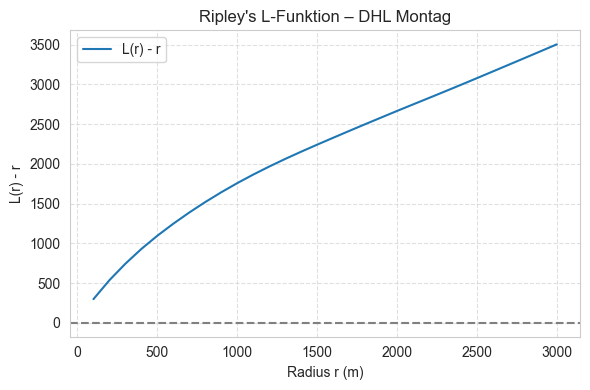

In [99]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

def ripley_k(points, radii, area):
    n_points = len(points)
    dists = distance_matrix(points, points)
    np.fill_diagonal(dists, np.inf)  # ignoriere Selbstabstand
    k_values = []

    for r in radii:
        count = np.sum(dists <= r)
        k = (area / (n_points * (n_points - 1))) * count
        k_values.append(k)

    return np.array(k_values)

# Punkte extrahieren
gdf = old_week["Monday"]
gdf = gdf[gdf[["dhl_b2b", "dhl_b2c"]].sum(axis=1) > 0].copy()
points = np.array([(geom.x, geom.y) for geom in gdf.geometry.centroid])

# Bounding Box Fläche
minx, miny, maxx, maxy = gdf.total_bounds
area = (maxx - minx) * (maxy - miny)

# Ripley's K & L
r_values = np.linspace(100, 3000, 30)
K = ripley_k(points, r_values, area)
L = np.sqrt(K / np.pi) - r_values

# Plot
plt.figure(figsize=(6, 4))
plt.plot(r_values, L, label="L(r) - r")
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Radius r (m)")
plt.ylabel("L(r) - r")
plt.title("Ripley's L-Funktion – DHL Montag")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.tight_layout()
plt.show()


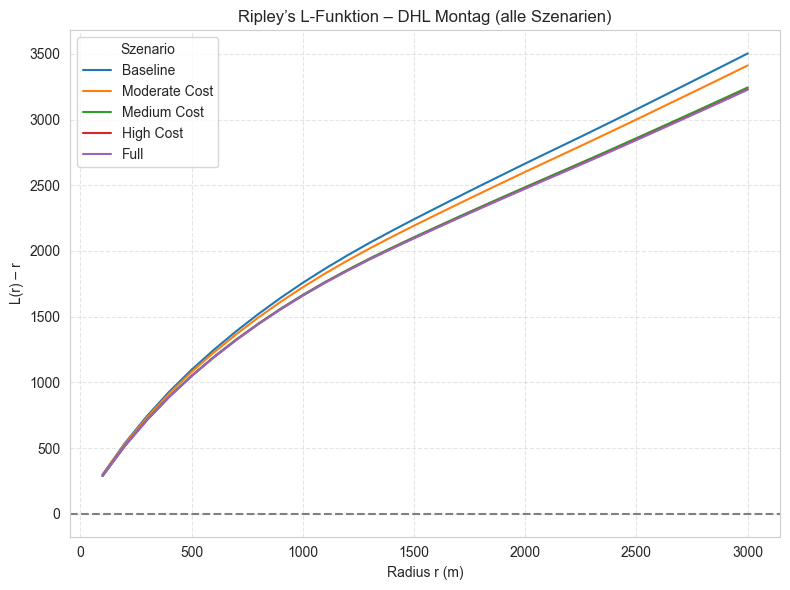

In [105]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.spatial import distance_matrix

import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

def ripley_k_fast(points, radii, area):
    tree = BallTree(points, metric='euclidean')
    n_points = len(points)
    if n_points < 2:
        return np.full_like(radii, np.nan)

    k_values = []
    for r in radii:
        # Für jeden Punkt: Anzahl Nachbarn im Radius r (inkl. sich selbst)
        counts = tree.query_radius(points, r=r, count_only=True)
        # Abziehen des Selbsttreffers und aufsummieren
        total = np.sum(counts - 1)
        k = (area / (n_points * (n_points - 1))) * total
        k_values.append(k)
    return np.array(k_values)

# Szenarienliste
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week)
]

# Radius-Stufen und Plotvorbereitung
r_values = np.linspace(100, 3000, 30)
plt.figure(figsize=(8, 6))

for scen_name, weekdict in scenarios:
    gdf = weekdict.get("Monday")
    if gdf is None or gdf.empty:
        continue

    # Punkte mit DHL-Sendungen
    gdf = gdf[gdf[["dhl_b2b", "dhl_b2c"]].sum(axis=1) > 0].copy()
    if gdf.empty:
        print(f"{scen_name}: Keine DHL-Punkte – übersprungen.")
        continue

    points = np.array([(geom.x, geom.y) for geom in gdf.geometry.centroid])
    minx, miny, maxx, maxy = gdf.total_bounds
    area = (maxx - minx) * (maxy - miny)

    # Ripley K & L(r) - r
    # K = ripley_k(points, r_values, area)
    K = ripley_k_fast(points, r_values, area)
    L = np.sqrt(K / np.pi) - r_values
    plt.plot(r_values, L, label=scen_name)

# Plot finalisieren
plt.axhline(0, linestyle="--", color="gray")
plt.xlabel("Radius r (m)")
plt.ylabel("L(r) – r")
plt.title("Ripley’s L-Funktion – DHL Montag (alle Szenarien)")
plt.legend(title="Szenario")
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


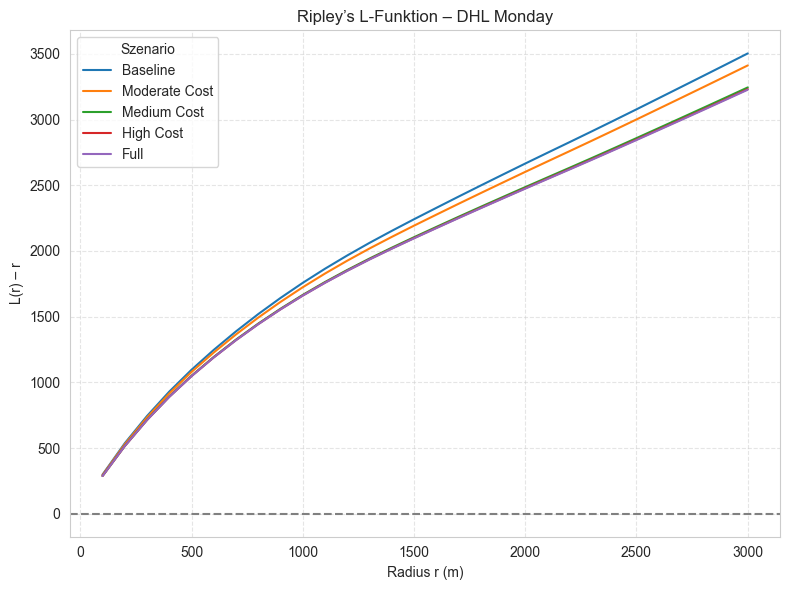

Full – Tuesday: Keine DHL-Sendungen.


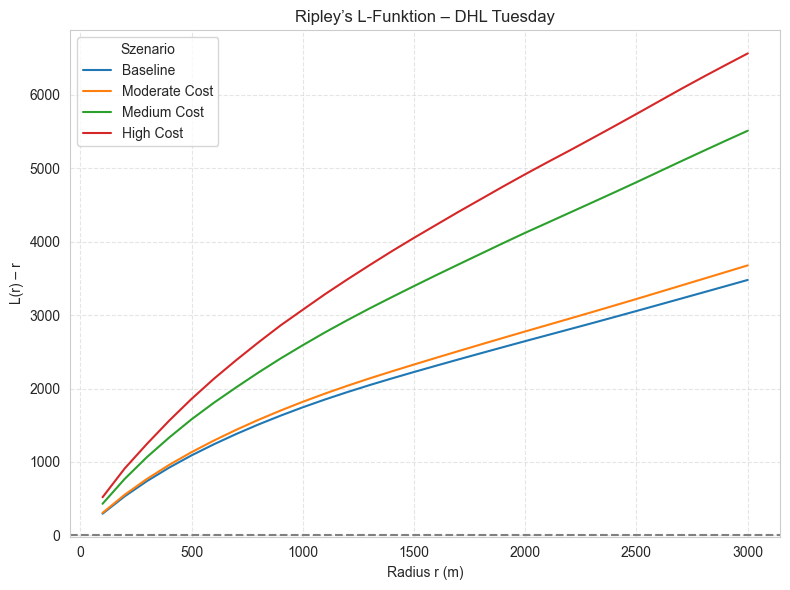

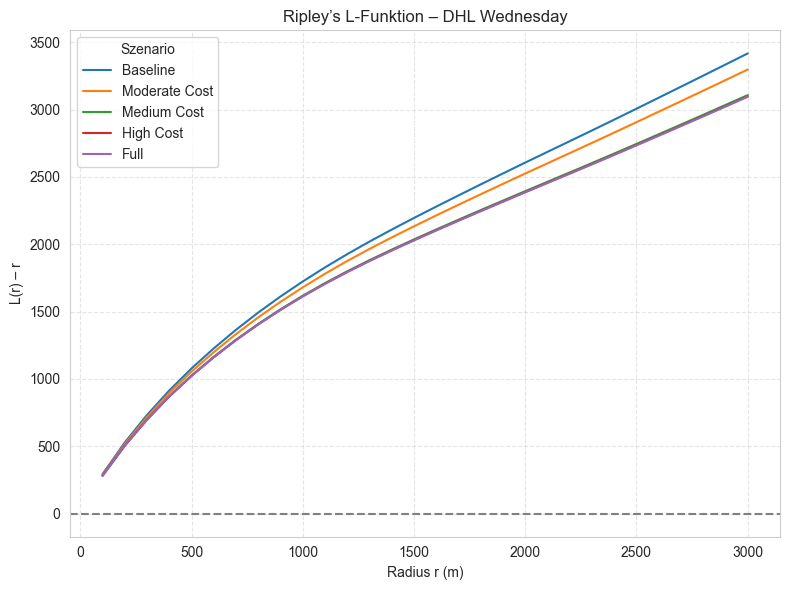

Full – Thursday: Keine DHL-Sendungen.


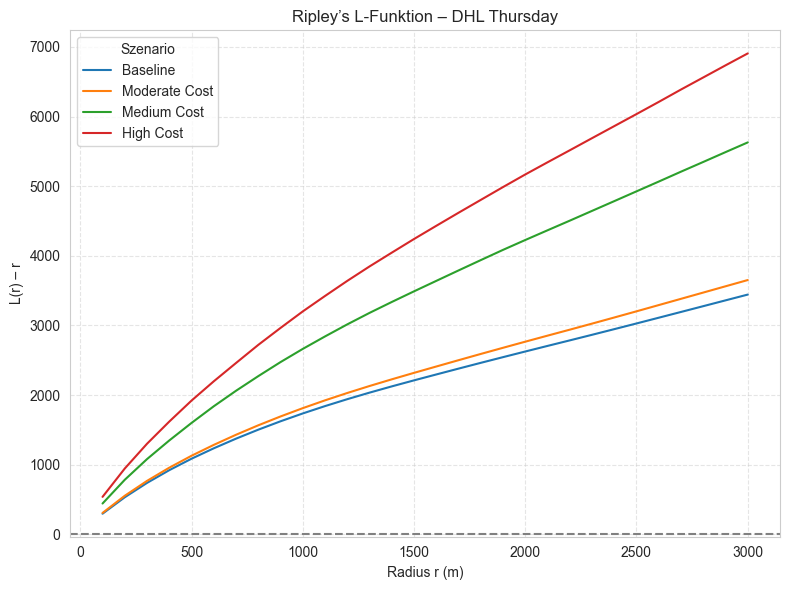

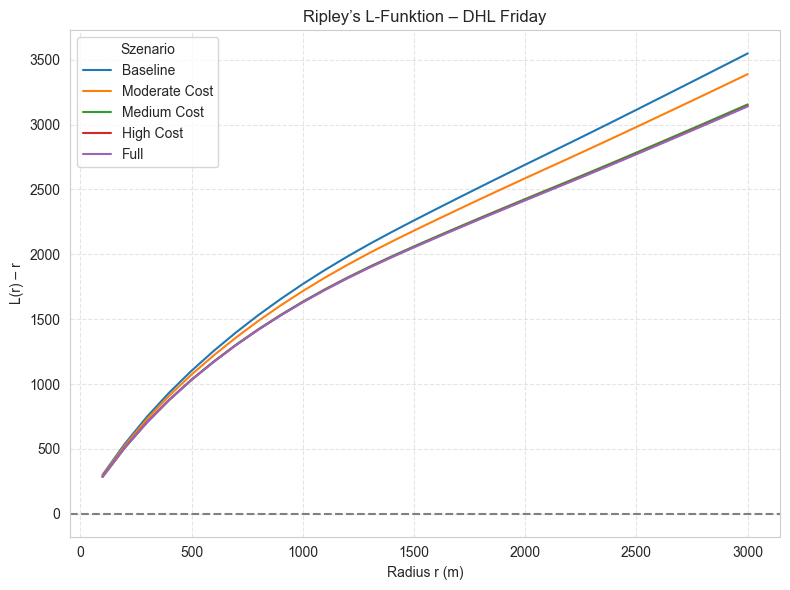

Full – Saturday: Keine DHL-Sendungen.


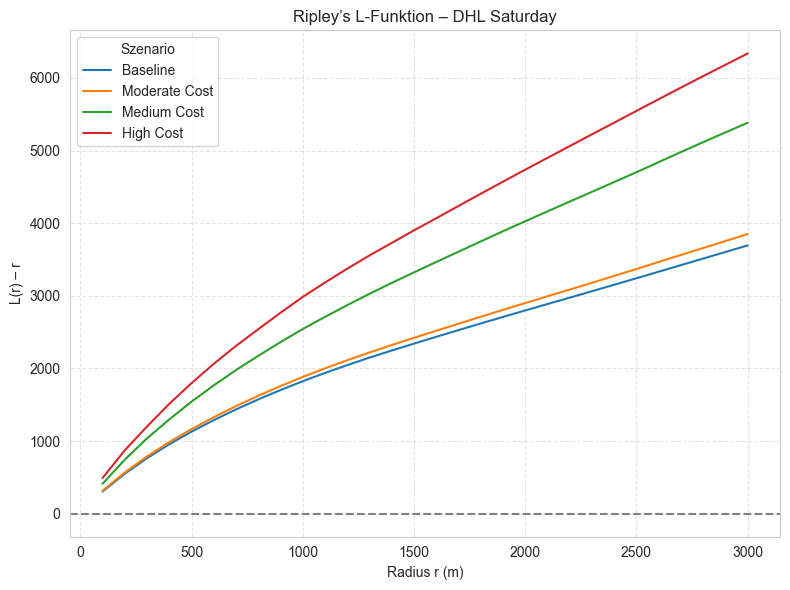

In [106]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import BallTree

# Schnelle Ripley-K-Berechnung
def ripley_k_fast(points, radii, area):
    tree = BallTree(points, metric='euclidean')
    n_points = len(points)
    if n_points < 2:
        return np.full_like(radii, np.nan)

    k_values = []
    for r in radii:
        counts = tree.query_radius(points, r=r, count_only=True)
        total = np.sum(counts - 1)
        k = (area / (n_points * (n_points - 1))) * total
        k_values.append(k)
    return np.array(k_values)

# Szenarien und Wochentage
scenarios = [
    ("Baseline", old_week),
    ("Moderate Cost", new_moderate_week),
    ("Medium Cost", new_medium_week),
    ("High Cost", new_high_week),
    ("Full", new_full_week)
]

weekdays = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday"]
r_values = np.linspace(100, 3000, 30)

# Durchlaufe jeden Wochentag
for day in weekdays:
    plt.figure(figsize=(8, 6))
    plotted = False

    for scen_name, weekdict in scenarios:
        gdf = weekdict.get(day)
        if gdf is None or gdf.empty:
            continue

        # Nur Zellen mit DHL-Sendungen
        gdf = gdf[gdf[["dhl_b2b", "dhl_b2c"]].sum(axis=1) > 0].copy()
        if gdf.empty:
            print(f"{scen_name} – {day}: Keine DHL-Sendungen.")
            continue

        # Punktkoordinaten extrahieren
        points = np.array([(geom.x, geom.y) for geom in gdf.geometry.centroid])
        minx, miny, maxx, maxy = gdf.total_bounds
        area = (maxx - minx) * (maxy - miny)

        # Ripley-K und L(r) – r berechnen
        K = ripley_k_fast(points, r_values, area)
        L = np.sqrt(K / np.pi) - r_values
        plt.plot(r_values, L, label=scen_name)
        plotted = True

    if plotted:
        plt.axhline(0, linestyle="--", color="gray")
        plt.xlabel("Radius r (m)")
        plt.ylabel("L(r) – r")
        plt.title(f"Ripley’s L-Funktion – DHL {day}")
        plt.legend(title="Szenario")
        plt.grid(True, linestyle="--", alpha=0.5)
        plt.tight_layout()
        plt.show()
    else:
        print(f"{day}: Kein gültiger Plot – alle Szenarien ohne Daten.")
